In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
df=pd.read_csv("C:/Users/Bhuva/Downloads/Amazon Sale Report.csv")

In [3]:
df.head(5)

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Category,Size,Courier Status,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,B2B,fulfilled-by,New,PendingS
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,...,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,...,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,...,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,...,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,...,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [4]:
df.shape


(128976, 21)

In [5]:
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Category', 'Size', 'Courier Status', 'Qty',
       'currency', 'Amount', 'ship-city', 'ship-state', 'ship-postal-code',
       'ship-country', 'B2B', 'fulfilled-by', 'New', 'PendingS'],
      dtype='object')

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   Order ID            128976 non-null  object 
 2   Date                128976 non-null  object 
 3   Status              128976 non-null  object 
 4   Fulfilment          128976 non-null  object 
 5   Sales Channel       128976 non-null  object 
 6   ship-service-level  128976 non-null  object 
 7   Category            128976 non-null  object 
 8   Size                128976 non-null  object 
 9   Courier Status      128976 non-null  object 
 10  Qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  Amount              121176 non-null  float64
 13  ship-city           128941 non-null  object 
 14  ship-state          128941 non-null  object 
 15  ship-postal-code    128941 non-nul

In [7]:
df.isnull().sum().sort_values(ascending=False)

PendingS              128976
New                   128976
fulfilled-by           89713
currency                7800
Amount                  7800
ship-country              35
ship-postal-code          35
ship-state                35
ship-city                 35
B2B                        0
index                      0
Order ID                   0
Courier Status             0
Size                       0
Category                   0
ship-service-level         0
Sales Channel              0
Fulfilment                 0
Status                     0
Date                       0
Qty                        0
dtype: int64

In [8]:
df.duplicated().sum()

168

In [9]:
df=df.drop_duplicates()


In [10]:
df.duplicated().sum()

0

In [11]:
df.isnull().all()

index                 False
Order ID              False
Date                  False
Status                False
Fulfilment            False
Sales Channel         False
ship-service-level    False
Category              False
Size                  False
Courier Status        False
Qty                   False
currency              False
Amount                False
ship-city             False
ship-state            False
ship-postal-code      False
ship-country          False
B2B                   False
fulfilled-by          False
New                    True
PendingS               True
dtype: bool

In [12]:
df.drop(columns=["New","PendingS"],inplace=True)

In [13]:
df.shape

(128808, 19)

In [14]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel',
 'ship-service-level',
 'Category',
 'Size',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'B2B',
 'fulfilled-by']

In [15]:
df['Date'].dtype

dtype('O')

In [16]:
df["Date"]=pd.to_datetime(
    df["Date"],errors="coerce",format="mixed")

In [17]:
df['Date'].dtype

dtype('<M8[ns]')

In [18]:
df["Year"]=df["Date"].dt.year
df["Month"]=df["Date"].dt.month
df["Month_Name"]=df["Date"].dt.month_name

In [19]:
df["Amount"].dtype

dtype('float64')

In [20]:
df["Amount"].isnull().sum()

7789

In [21]:
sales_df=df[df["Amount"].notna()].copy()

In [22]:
sales_df.shape

(121019, 22)

In [23]:
df["Qty"].describe()

count    128808.000000
mean          0.904416
std           0.313373
min           0.000000
25%           1.000000
50%           1.000000
75%           1.000000
max          15.000000
Name: Qty, dtype: float64

In [24]:
df["Qty"].isnull().sum()

0

In [25]:
len(df)

128808

In [26]:
df["Order ID"].nunique()

120229

In [27]:
df.columns.tolist()

['index',
 'Order ID',
 'Date',
 'Status',
 'Fulfilment',
 'Sales Channel',
 'ship-service-level',
 'Category',
 'Size',
 'Courier Status',
 'Qty',
 'currency',
 'Amount',
 'ship-city',
 'ship-state',
 'ship-postal-code',
 'ship-country',
 'B2B',
 'fulfilled-by',
 'Year',
 'Month',
 'Month_Name']

In [28]:
df["Order ID"].nunique()

120229

In [29]:
df["Order ID"].duplicated().sum()

8579

In [30]:
df["Category"].value_counts()

Category
T-shirt     50219
Shirt       49804
Blazzer     15489
Trousers    10607
Perfume      1157
Wallet        926
Socks         439
Shoes         164
Watch           3
Name: count, dtype: int64

In [31]:
sales_df.groupby("Category")["Amount"].sum().sort_values(ascending=False)

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64

In [32]:
df["Status"].value_counts()

Status
Shipped                          77713
Shipped - Delivered to Buyer     28715
Cancelled                        18311
Shipped - Returned to Seller      1952
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64

In [33]:
df["Fulfilment"].value_counts()

Fulfilment
Amazon      89595
Merchant    39213
Name: count, dtype: int64

In [34]:
df["B2B"].value_counts()

B2B
False    127937
True        871
Name: count, dtype: int64

In [35]:
df["ship-state"].nunique()

69

In [36]:
df["ship-state"].value_counts().head(10)

ship-state
MAHARASHTRA       22234
KARNATAKA         17296
TAMIL NADU        11470
TELANGANA         11319
UTTAR PRADESH     10633
DELHI              6770
KERALA             6574
WEST BENGAL        5955
ANDHRA PRADESH     5421
Gujarat            4479
Name: count, dtype: int64

In [37]:
df["ship-city"].value_counts().head(10)

ship-city
BENGALURU    11191
HYDERABAD     8067
MUMBAI        6115
NEW DELHI     5784
CHENNAI       5421
PUNE          3856
KOLKATA       2378
GURUGRAM      1865
THANE         1700
LUCKNOW       1458
Name: count, dtype: int64

In [38]:
total_orders=df["Order ID"].nunique()
print("Total Unique Orders:",total_orders)

Total Unique Orders: 120229


In [39]:
total_quantity=df["Qty"].sum()
print("Total Quantity Sold:",total_quantity)

Total Quantity Sold: 116496


In [40]:
total_sales=sales_df["Amount"].sum()
print("Total Sales Amount:",round(total_sales,2))

Total Sales Amount: 78496786.39


In [41]:
orders_with_amount=sales_df["Order ID"].nunique()
aov=total_sales/orders_with_amount
print("Order with Amount:",orders_with_amount)
print("Average Order Value:",round(aov,2))

Order with Amount: 112887
Average Order Value: 695.36


In [42]:
status_count=df["Status"].value_counts()
print(status_count)

Status
Shipped                          77713
Shipped - Delivered to Buyer     28715
Cancelled                        18311
Shipped - Returned to Seller      1952
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


In [43]:
status_percent=df["Status"].value_counts(normalize=True)*100
print(status_percent.round(2))

Status
Shipped                          60.33
Shipped - Delivered to Buyer     22.29
Cancelled                        14.22
Shipped - Returned to Seller      1.52
Shipped - Picked Up               0.76
Pending                           0.51
Pending - Waiting for Pick Up     0.22
Shipped - Returning to Seller     0.11
Shipped - Out for Delivery        0.03
Shipped - Rejected by Buyer       0.01
Shipping                          0.01
Shipped - Lost in Transit         0.00
Shipped - Damaged                 0.00
Name: proportion, dtype: float64


In [44]:
cancelled_orders=df.loc[
df["Status"]=="Cancelled","Order ID"].nunique()
cancellation_rate=(cancelled_orders/total_orders)*100
print("Cancelled Unique Orders:",cancelled_orders)
print("Cancelled Rate:",round(cancellation_rate,2),"%")

Cancelled Unique Orders: 17166
Cancelled Rate: 14.28 %


In [45]:
returned_orders=df.loc[df["Status"].isin(["Shipped - Returned to Seller","Shipped - Returning to Seller"]),"Order ID"].nunique()
return_rate=(returned_orders/total_orders)*100
print("Returned Unique Orders:",returned_orders)
print("Return Rate:",round(return_rate,2),"%")

Returned Unique Orders: 1980
Return Rate: 1.65 %


In [46]:
monthly_sales=(sales_df.groupby(sales_df["Date"].dt.to_period("M"))["Amount"].sum())
print(monthly_sales)

Date
2022-03      101683.85
2022-04    28742816.41
2022-05    26226476.75
2022-06    23425809.38
Freq: M, Name: Amount, dtype: float64


In [47]:
best_month=monthly_sales.idxmax()
best_month_sales=monthly_sales.max()
print("Best Month:",best_month)
print("Sales:",round(best_month_sales,2))

Best Month: 2022-04
Sales: 28742816.41


In [48]:
lowest_month=monthly_sales.idxmin()
lowest_month_sales=monthly_sales.min()
print("Lowest Month:",lowest_month)
print("Sales:",round(lowest_month_sales,2))

Lowest Month: 2022-03
Sales: 101683.85


In [49]:
monthly_sales

Date
2022-03      101683.85
2022-04    28742816.41
2022-05    26226476.75
2022-06    23425809.38
Freq: M, Name: Amount, dtype: float64

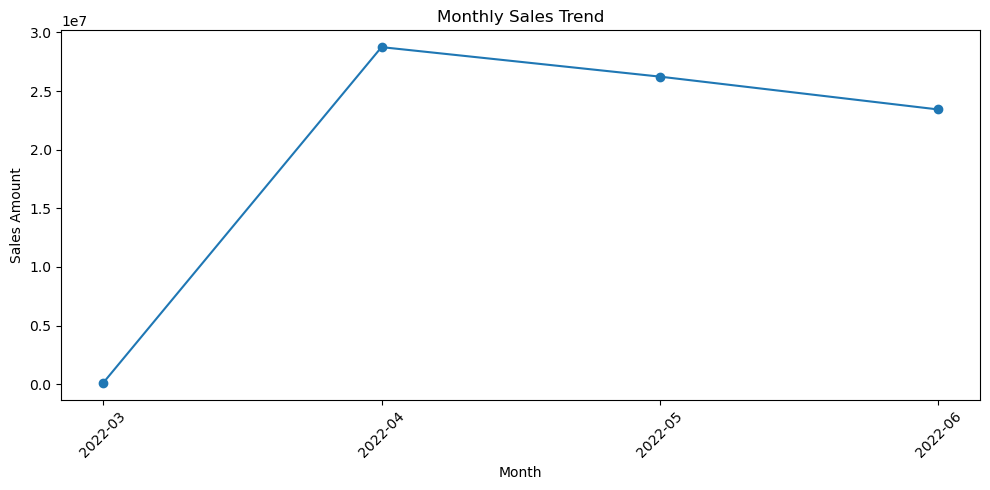

In [50]:
plt.figure(figsize=(10,5))
plt.plot(monthly_sales.index.astype(str),monthly_sales.values,marker="o")
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [51]:
monthly_orders=(df.groupby(df["Date"].dt.to_period("M"))["Order ID"].nunique())
print(monthly_orders)

Date
2022-03      158
2022-04    45709
2022-05    39221
2022-06    35141
Freq: M, Name: Order ID, dtype: int64


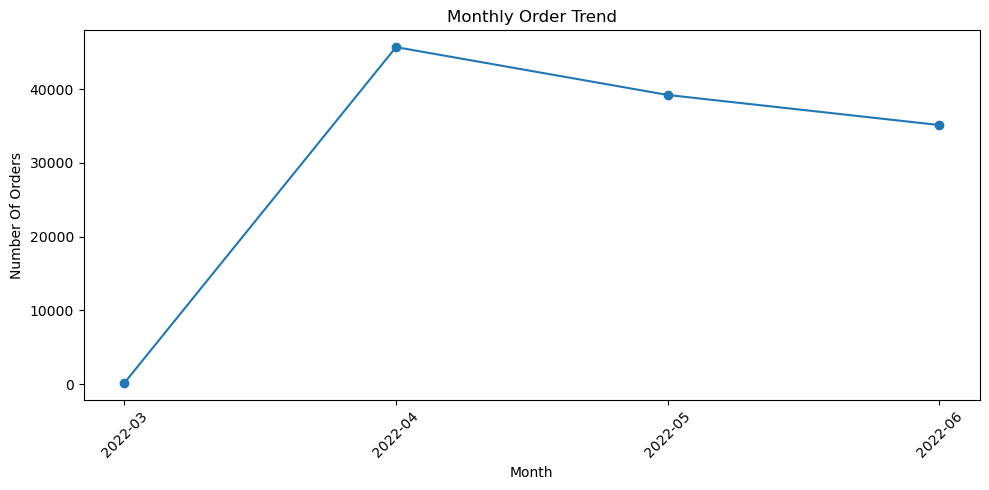

In [52]:
plt.figure(figsize=(10,5))
plt.plot(monthly_orders.index.astype(str),monthly_orders.values,marker="o")
plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number Of Orders")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [53]:
monthly_aov=(sales_df.groupby(sales_df["Date"].dt.to_period("M"))
             .agg(Sales=("Amount","sum"),Orders=("Order ID","nunique")))
monthly_aov["AOV"]=(monthly_aov["Sales"]/monthly_aov["Orders"])
print(monthly_aov)

               Sales  Orders         AOV
Date                                    
2022-03    101683.85     150  677.892333
2022-04  28742816.41   42886  670.214439
2022-05  26226476.75   36865  711.419415
2022-06  23425809.38   32986  710.174298


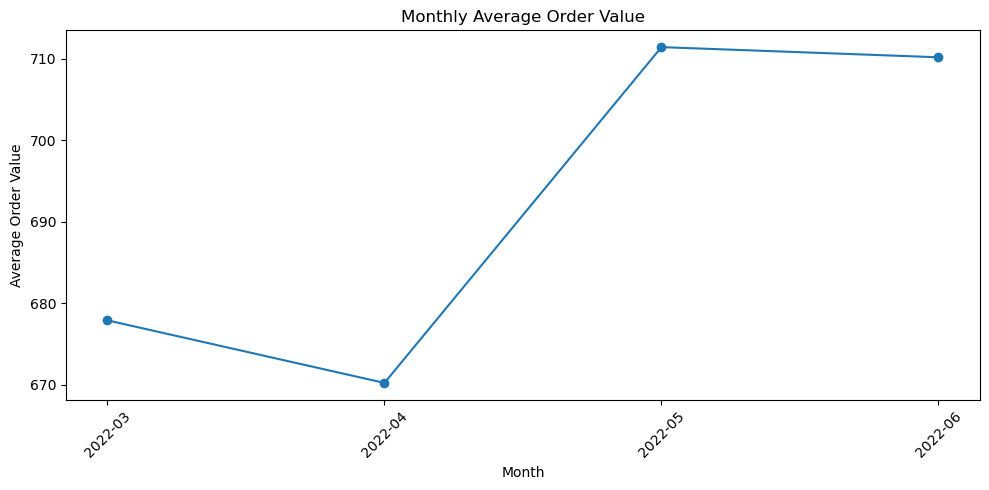

In [54]:
plt.figure(figsize=(10,5))
plt.plot(monthly_aov.index.astype(str),monthly_aov["AOV"],marker="o")
plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [55]:
status_counts=df["Status"].value_counts()
print(status_counts)

Status
Shipped                          77713
Shipped - Delivered to Buyer     28715
Cancelled                        18311
Shipped - Returned to Seller      1952
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shipped - Out for Delivery          35
Shipped - Rejected by Buyer         11
Shipping                             8
Shipped - Lost in Transit            5
Shipped - Damaged                    1
Name: count, dtype: int64


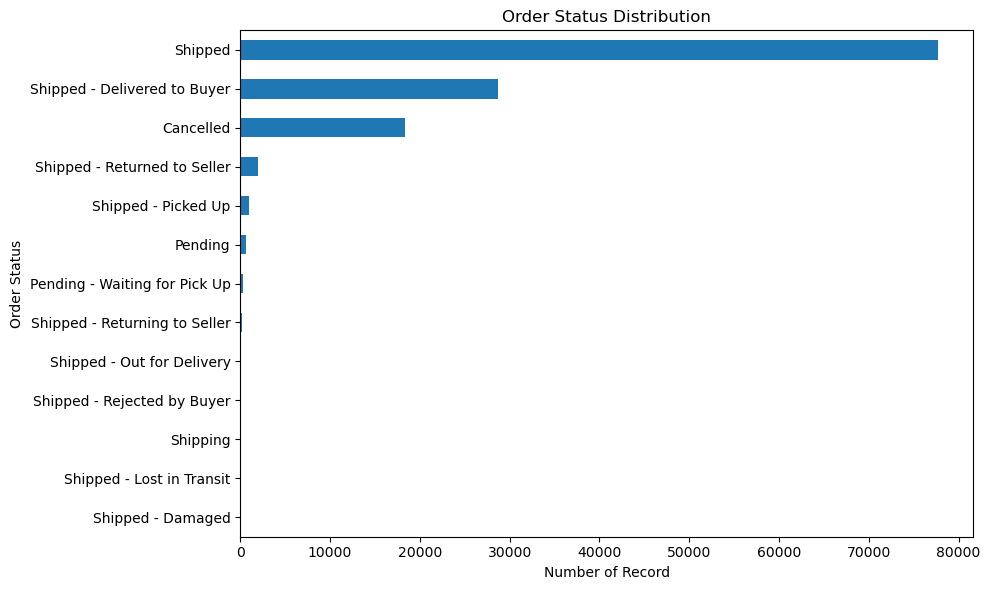

In [56]:
plt.figure(figsize=(10,6))
status_counts.sort_values().plot(kind="barh")
plt.title("Order Status Distribution")
plt.xlabel("Number of Record")
plt.ylabel("Order Status")
plt.tight_layout()
plt.show()

In [57]:
cancelled_order_ids=set(df.loc[df["Status"]=="Cancelled","Order ID"])
df["Order_Type"]=np.where(df["Order ID"].isin(cancelled_order_ids),"Cancelled","Not Cancelled")
order_type_counts=(df.drop_duplicates("Order ID")["Order_Type"].value_counts())
print(order_type_counts)

Order_Type
Not Cancelled    103063
Cancelled         17166
Name: count, dtype: int64


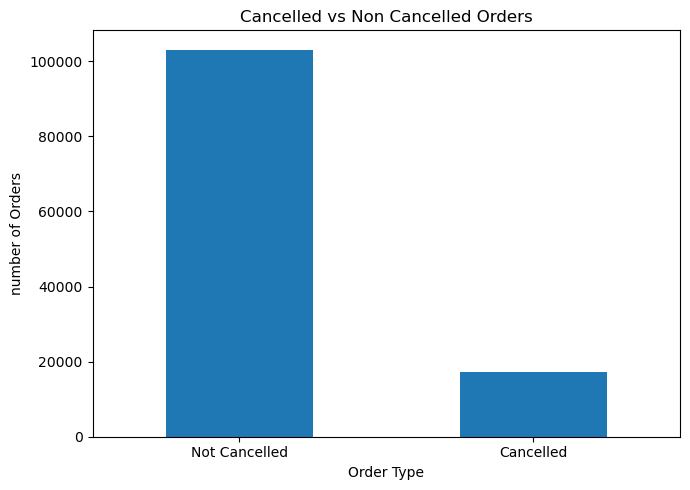

In [58]:
plt.figure(figsize=(7,5))
order_type_counts.plot(kind="bar")
plt.title("Cancelled vs Non Cancelled Orders")
plt.xlabel("Order Type")
plt.ylabel("number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [59]:
stage2_kpis=pd.DataFrame({"KPI":["Total Unique Orders","Total Quantity Sold","Orders with Amount","Total Sales Amount","Average Order Value","Cancelled Orders","Cancellation Rate","Returned Orders","Return Rate(%)"],"Value":[total_orders,total_quantity,orders_with_amount,total_sales,aov,cancelled_orders,cancellation_rate,returned_orders,return_rate]})
stage2_kpis

,KPI,Value
0,Total Unique Orders,1.202290e+05
1,Total Quantity Sold,1.164960e+05
2,Orders with Amount,1.128870e+05
3,Total Sales Amount,7.849679e+07
4,Average Order Value,6.953572e+02
5,Cancelled Orders,1.716600e+04
6,Cancellation Rate,1.427775e+01
7,Returned Orders,1.980000e+03
8,Return Rate(%),1.646857e+00


In [60]:
stage2_kpis["Value"]=stage2_kpis["Value"].round(2)
stage2_kpis

,KPI,Value
0,Total Unique Orders,120229.00
1,Total Quantity Sold,116496.00
2,Orders with Amount,112887.00
3,Total Sales Amount,78496786.39
4,Average Order Value,695.36
5,Cancelled Orders,17166.00
6,Cancellation Rate,14.28
7,Returned Orders,1980.00
8,Return Rate(%),1.65


In [61]:
category_orders=(df.groupby("Category")["Order ID"].nunique().sort_values(ascending=False))
print(category_orders)

Category
T-shirt     47782
Shirt       46499
Blazzer     14984
Trousers    10141
Perfume      1146
Wallet        897
Socks         409
Shoes         144
Watch           2
Name: Order ID, dtype: int64


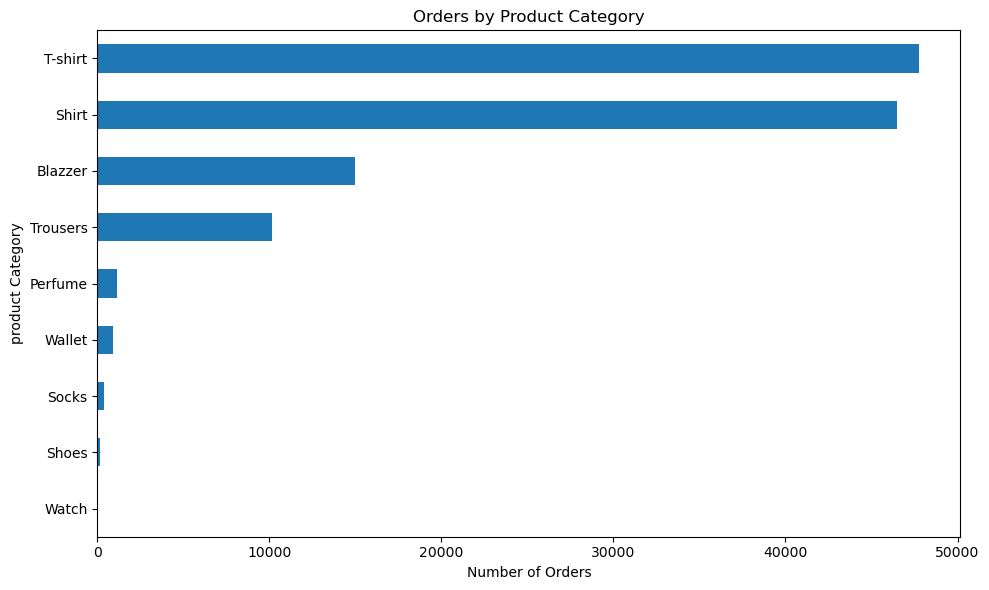

In [62]:
plt.figure(figsize=(10,6))
category_orders.sort_values().plot(kind="barh")
plt.title("Orders by Product Category")
plt.xlabel("Number of Orders")
plt.ylabel("product Category")
plt.tight_layout()
plt.show()

Category
T-shirt     45228
Shirt       44978
Blazzer     13934
Trousers     9889
Perfume      1051
Wallet        863
Socks         398
Shoes         152
Watch           3
Name: Qty, dtype: int64


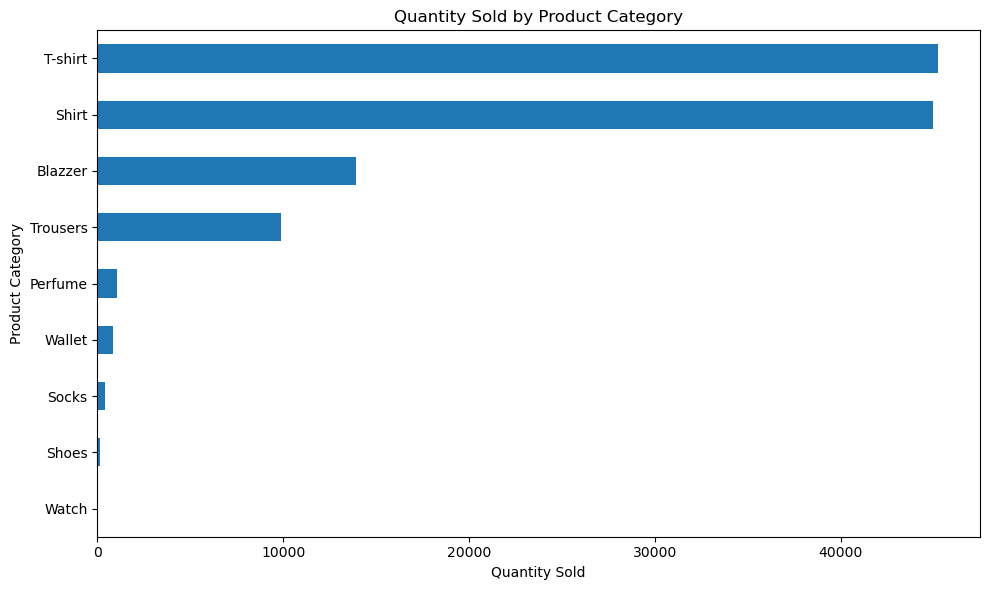

In [63]:
category_quantity=(df.groupby("Category")["Qty"].sum().sort_values(ascending=False))
print(category_quantity)
plt.figure(figsize=(10,6))
category_quantity.sort_values().plot(kind="barh")
plt.title("Quantity Sold by Product Category")
plt.xlabel("Quantity Sold")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64


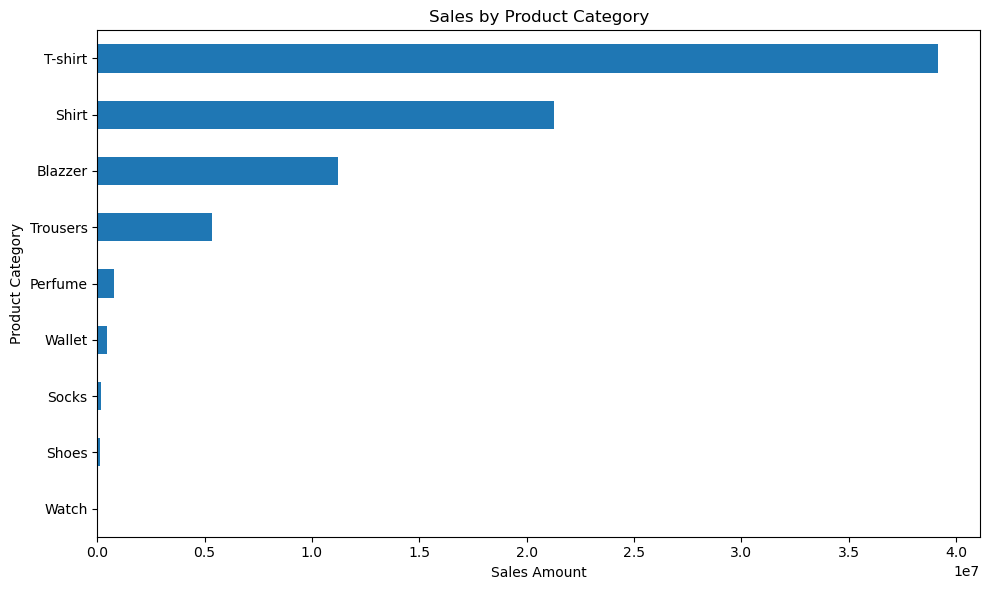

In [64]:
category_sales=(sales_df.groupby("Category")["Amount"].sum().sort_values(ascending=False))
print(category_sales)
plt.figure(figsize=(10,6))
category_sales.sort_values().plot(kind="barh")
plt.title("Sales by Product Category")
plt.xlabel("Sales Amount")
plt.ylabel("Product Category")
plt.tight_layout()
plt.show()


Category
T-shirt     49.88
Shirt       27.10
Blazzer     14.28
Trousers     6.80
Perfume      1.01
Wallet       0.58
Socks        0.19
Shoes        0.16
Watch        0.00
Name: Amount, dtype: float64


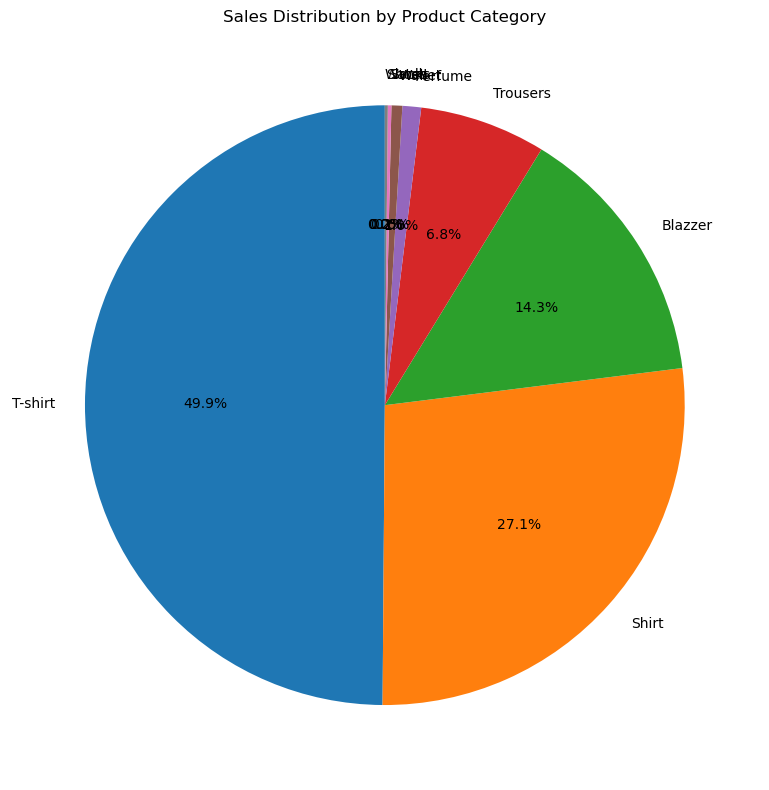

In [65]:
category_sales_percentage=(category_sales/category_sales.sum())*100
print(category_sales_percentage.round(2))
plt.figure(figsize=(8,8))
category_sales_percentage.plot(kind="pie",autopct="%1.1f%%",startangle=90)
plt.title("Sales Distribution by Product Category")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [66]:
print(df["Size"].value_counts())

Size
M       22350
L       21777
XL      20520
XXL     17783
S       16754
3XL     14626
XS      11033
Free     2250
6XL       738
5XL       550
4XL       427
Name: count, dtype: int64


In [67]:
size_orders=(df.groupby("Size")["Order ID"].nunique().sort_values(ascending=False))
print(size_orders)

Size
M       21386
L       20726
XL      19565
XXL     16874
S       16023
3XL     13584
XS      10416
Free     2189
6XL       681
5XL       526
4XL       394
Name: Order ID, dtype: int64


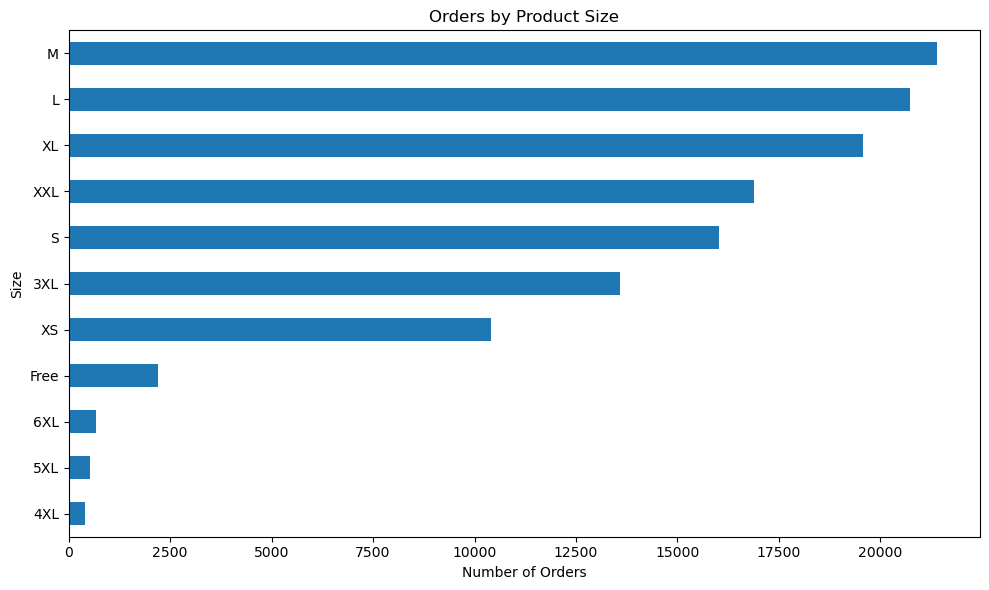

In [68]:
plt.figure(figsize=(10,6))
size_orders.sort_values().plot(kind="barh")
plt.title("Orders by Product Size")
plt.xlabel("Number of Orders")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

Size
M       20116
L       19680
XL      18609
XXL     16226
S       15022
3XL     13346
XS       9829
Free     2069
6XL       688
5XL       513
4XL       398
Name: Qty, dtype: int64


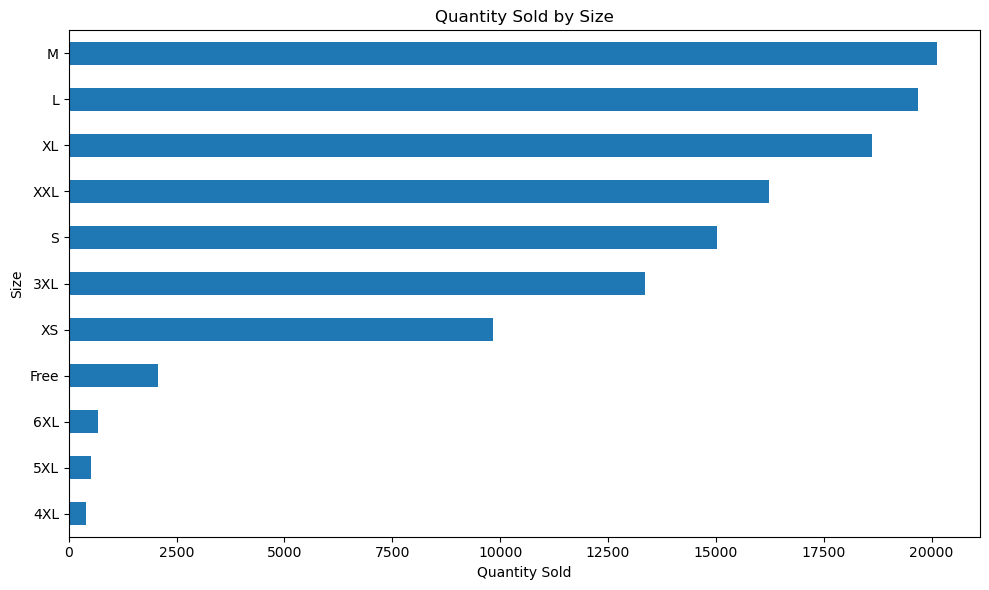

In [69]:
size_quantity=(df.groupby("Size")["Qty"].sum().sort_values(ascending=False))
print(size_quantity)
plt.figure(figsize=(10,6))
size_quantity.sort_values().plot(kind="barh")
plt.title("Quantity Sold by Size")
plt.xlabel("Quantity Sold")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

Size
M       13678295.13
L       13023938.84
XL      12240095.38
XXL     10452621.64
S       10414943.18
3XL      9026104.92
XS       6952253.10
Free     1372676.60
6XL       576249.33
5XL       425156.63
4XL       334451.64
Name: Amount, dtype: float64


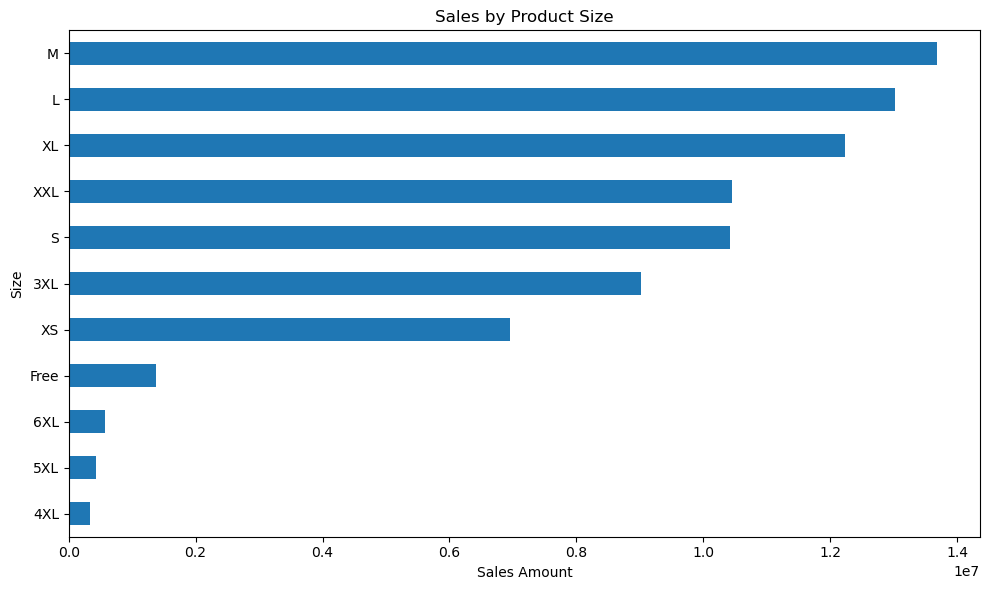

In [70]:
size_sales=(sales_df.groupby("Size")["Amount"].sum().sort_values(ascending=False))
print(size_sales)
plt.figure(figsize=(10,6))
size_sales.sort_values().plot(kind="barh")
plt.title("Sales by Product Size")
plt.xlabel("Sales Amount")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

Size
M       13678295.13
L       13023938.84
XL      12240095.38
XXL     10452621.64
S       10414943.18
3XL      9026104.92
XS       6952253.10
Free     1372676.60
6XL       576249.33
5XL       425156.63
4XL       334451.64
Name: Amount, dtype: float64


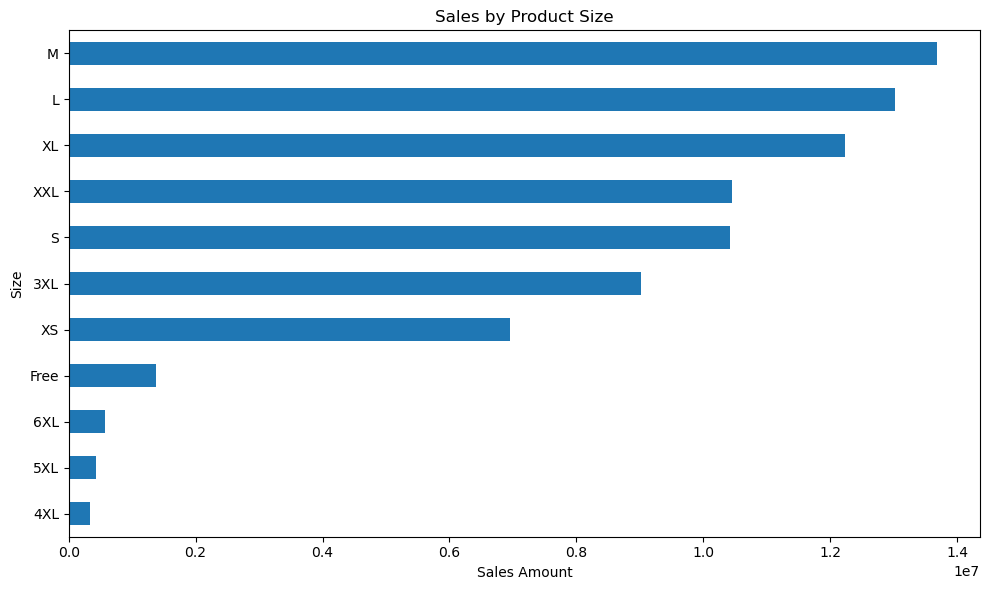

In [71]:
size_sales=(sales_df.groupby("Size")["Amount"].sum().sort_values(ascending=False))
print(size_sales)
plt.figure(figsize=(10,6))
size_sales.sort_values().plot(kind="barh")
plt.title("Sales by Product Size")
plt.xlabel("Sales Amount")
plt.ylabel("Size")
plt.tight_layout()
plt.show()

In [72]:
category_size_quantity=pd.pivot_table(df,values="Qty",index="Category",columns="Size",aggfunc="sum",fill_value=0)
category_size_quantity

Size,3XL,4XL,5XL,6XL,Free,L,M,S,XL,XS,XXL
Category,,,,,,,,,,,
Blazzer,1758,0,0,0,0,2543,2325,1962,2123,1279,1944
Perfume,0,0,0,0,1051,0,0,0,0,0,0
Shirt,5126,352,456,616,0,8036,7701,5154,7825,2778,6934
Shoes,0,0,0,0,152,0,0,0,0,0,0
Socks,60,0,0,0,0,67,50,67,64,26,64
T-shirt,5282,46,57,72,0,7388,8348,6694,6865,4878,5598
Trousers,1120,0,0,0,0,1646,1692,1145,1732,868,1686
Wallet,0,0,0,0,863,0,0,0,0,0,0
Watch,0,0,0,0,3,0,0,0,0,0,0


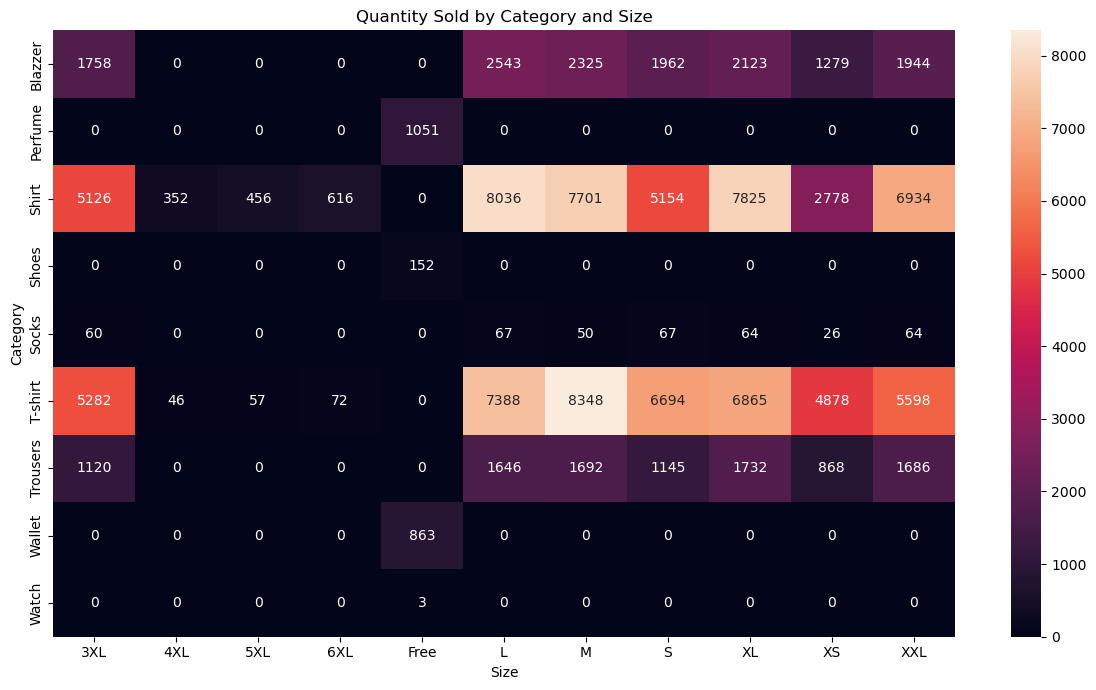

In [73]:
plt.figure(figsize=(12,7))
sns.heatmap(category_size_quantity,annot=True,fmt=".0f")
plt.title("Quantity Sold by Category and Size")
plt.xlabel("Size")
plt.ylabel("Category")
plt.tight_layout()
plt.show()

In [74]:
best_category=category_sales.idxmax()
best_category_sales=category_sales.max()
print("Best Selling Category:",best_category)
print("Sales:",round(best_category_sales,2))

Best Selling Category: T-shirt
Sales: 39154132.17


In [75]:
best_size=size_sales.idxmax()
best_size_sales=size_sales.max()
print("best selling Size:",best_size)
print("sales:",round(best_size_sales,2))

best selling Size: M
sales: 13678295.13


In [76]:
stage3=pd.DataFrame({"Metric":["Best Selling Category","Best Category Sales","Best Selling Price","Best Size Sales"],"Value":[best_category,best_category_sales,best_size,best_size_sales]})
stage3

,Metric,Value
0,Best Selling Category,T-shirt
1,Best Category Sales,39154132.17
2,Best Selling Price,M
3,Best Size Sales,13678295.13


In [77]:
category_size_sales = pd.pivot_table(sales_df,values="Amount",index="Category",columns="Size",aggfunc="sum",fill_value=0)
category_size_sales

Size,3XL,4XL,5XL,6XL,Free,L,M,S,XL,XS,XXL
Category,,,,,,,,,,,
Blazzer,1406828.11,0.00,0.00,0.00,0.00,2024665.69,1879021.49,1602174.85,1724742.99,998881.05,1572191.94
Perfume,0.00,0.00,0.00,0.00,789419.66,0.00,0.00,0.00,0.00,0.00,0.00
Shirt,2450631.96,277139.40,357467.63,485831.26,0.00,3726898.17,3542099.45,2350045.64,3627000.95,1236263.34,3216390.90
Shoes,0.00,0.00,0.00,0.00,123933.76,0.00,0.00,0.00,0.00,0.00,0.00
Socks,24332.63,0.00,0.00,0.00,0.00,25031.21,19580.59,22598.76,25879.63,9491.72,23482.96
T-shirt,4526568.41,57312.24,67689.00,90418.07,0.00,6347404.91,7295446.89,5823312.31,5930367.97,4258351.52,4757260.85
Trousers,617743.81,0.00,0.00,0.00,0.00,899938.86,942146.71,616811.62,932103.84,449265.47,883294.99
Wallet,0.00,0.00,0.00,0.00,458408.18,0.00,0.00,0.00,0.00,0.00,0.00
Watch,0.00,0.00,0.00,0.00,915.00,0.00,0.00,0.00,0.00,0.00,0.00


In [78]:
max_position = category_size_sales.stack().idxmax()
max_value = category_size_sales.stack().max()

print("Highest-Selling Category-Size Combination:", max_position)
print("Sales:", round(max_value, 2))

Highest-Selling Category-Size Combination: ('T-shirt', 'M')
Sales: 7295446.89


In [79]:
df["Fulfilment"].value_counts()

Fulfilment
Amazon      89595
Merchant    39213
Name: count, dtype: int64

In [80]:
fulfillment_orders = (df.groupby("Fulfilment")["Order ID"].nunique().sort_values(ascending=False))
print(fulfillment_orders)

Fulfilment
Amazon      83906
Merchant    36323
Name: Order ID, dtype: int64


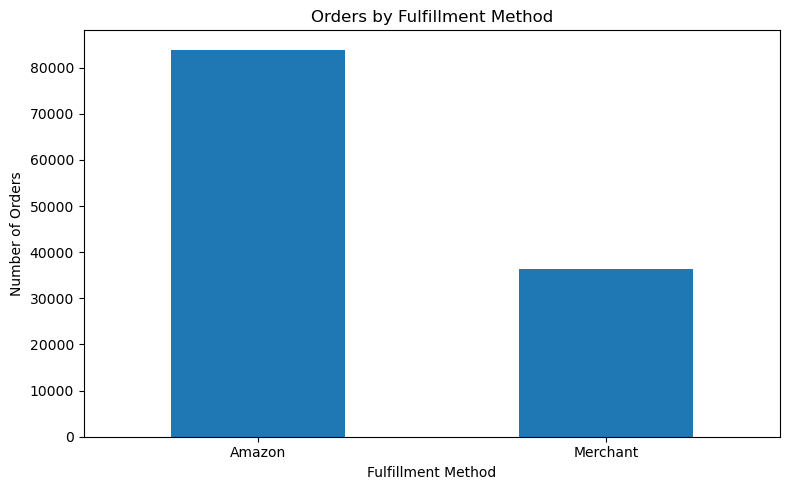

In [81]:
plt.figure(figsize=(8, 5))
fulfillment_orders.plot(kind="bar")
plt.title("Orders by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Number of Orders")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [82]:
fulfillment_quantity = (df.groupby("Fulfilment")["Qty"].sum().sort_values(ascending=False))
print(fulfillment_quantity)

Fulfilment
Amazon      83990
Merchant    32506
Name: Qty, dtype: int64


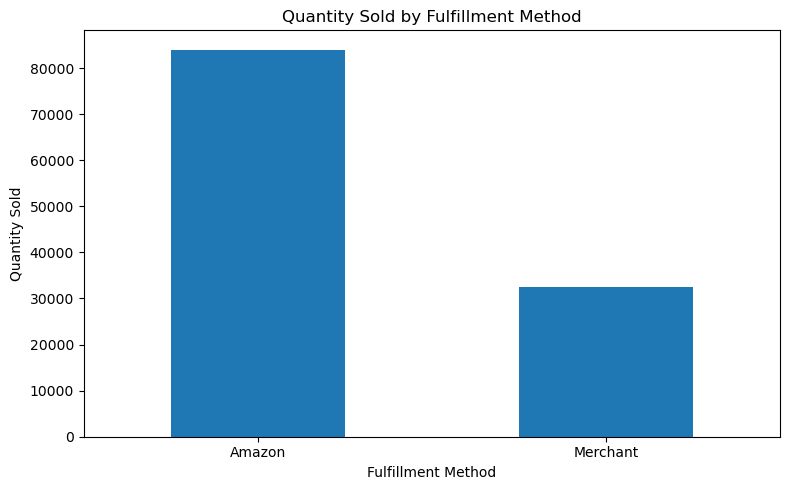

In [83]:
plt.figure(figsize=(8, 5))
fulfillment_quantity.plot(kind="bar")
plt.title("Quantity Sold by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [84]:
fulfillment_sales = (sales_df.groupby("Fulfilment")["Amount"].sum().sort_values(ascending=False))
print(fulfillment_sales)

Fulfilment
Amazon      54262165.00
Merchant    24234621.39
Name: Amount, dtype: float64


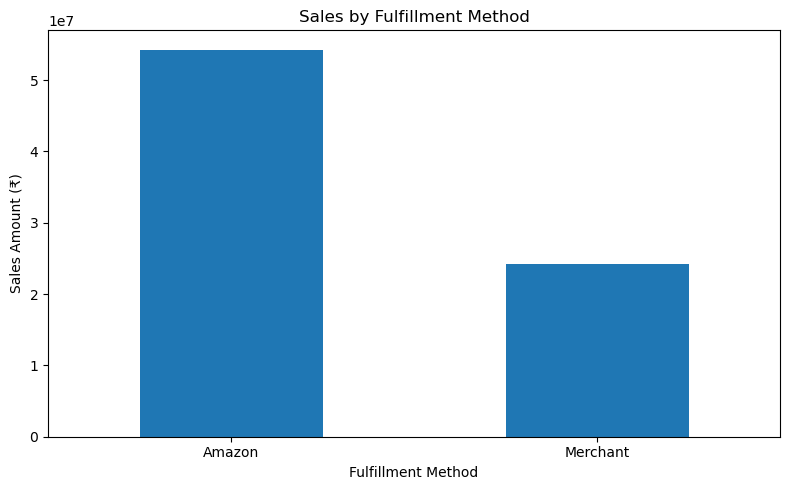

In [85]:
plt.figure(figsize=(8, 5))
fulfillment_sales.plot(kind="bar")
plt.title("Sales by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [86]:
fulfillment_aov = (sales_df.groupby("Fulfilment").agg(Sales=("Amount", "sum"),Orders=("Order ID", "nunique")))
fulfillment_aov["AOV"] = (fulfillment_aov["Sales"] /fulfillment_aov["Orders"])
print(fulfillment_aov)

                  Sales  Orders         AOV
Fulfilment                                 
Amazon      54262165.00   78211  693.791986
Merchant    24234621.39   34676  698.887455


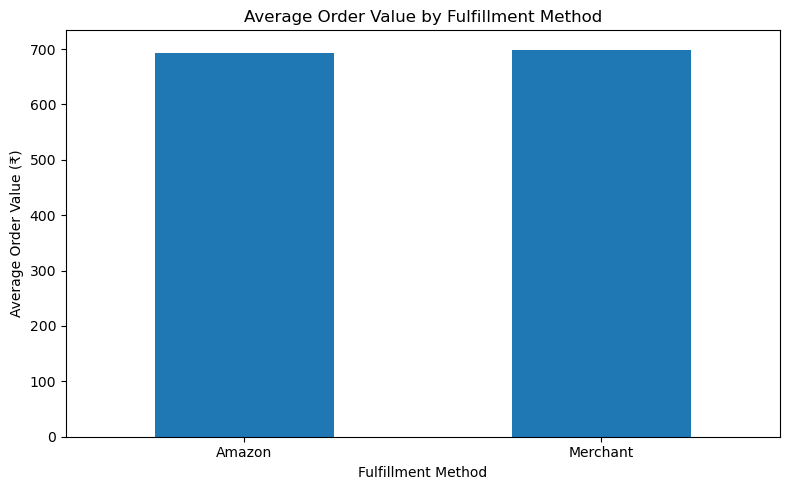

In [87]:
plt.figure(figsize=(8, 5))
fulfillment_aov["AOV"].plot(kind="bar")
plt.title("Average Order Value by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Average Order Value (₹)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [88]:
fulfillment_status = pd.crosstab(df["Fulfilment"],df["Status"])
fulfillment_status

Status,Cancelled,Pending,Pending - Waiting for Pick Up,Shipped,Shipped - Damaged,Shipped - Delivered to Buyer,Shipped - Lost in Transit,Shipped - Out for Delivery,Shipped - Picked Up,Shipped - Rejected by Buyer,Shipped - Returned to Seller,Shipped - Returning to Seller,Shipping
Fulfilment,,,,,,,,,,,,,
Amazon,11459,415,0,77713,0,0,0,0,0,0,0,0,8
Merchant,6852,243,281,0,1,28715,5,35,973,11,1952,145,0


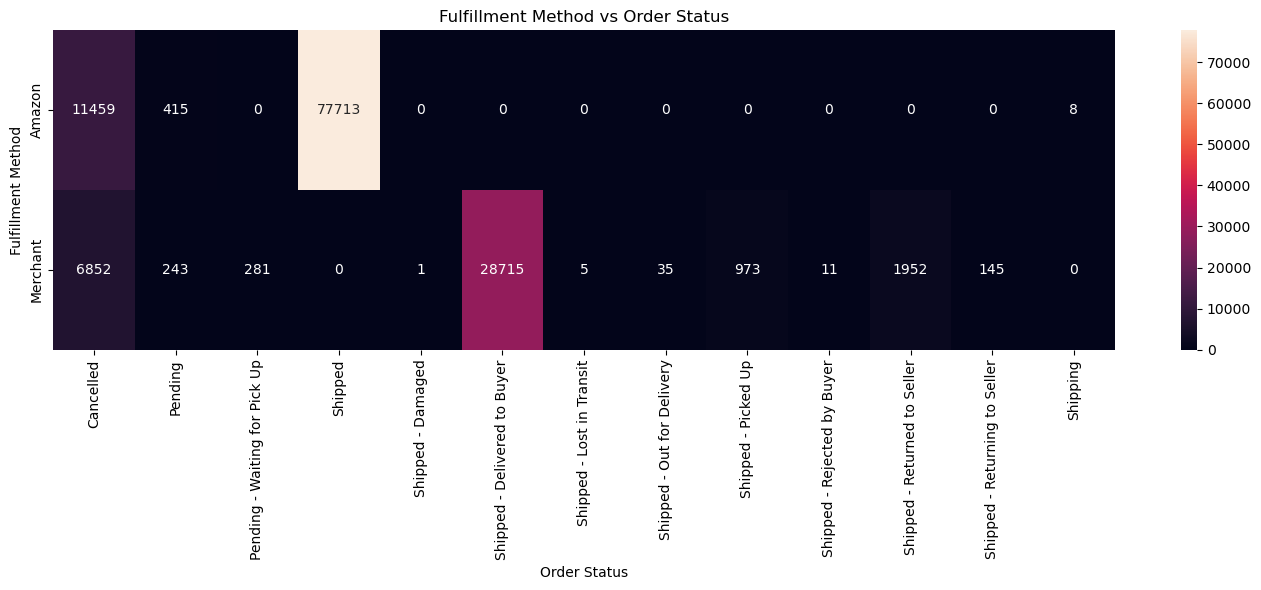

In [89]:
plt.figure(figsize=(14, 6))
sns.heatmap(fulfillment_status,annot=True,fmt="d")
plt.title("Fulfillment Method vs Order Status")
plt.xlabel("Order Status")
plt.ylabel("Fulfillment Method")
plt.tight_layout()
plt.show()

In [90]:
cancelled_by_fulfillment = (df[df["Status"] == "Cancelled"].groupby("Fulfilment")["Order ID"].nunique())
print(cancelled_by_fulfillment)

Fulfilment
Amazon      10791
Merchant     6375
Name: Order ID, dtype: int64


In [91]:
total_orders_by_fulfillment = (df.groupby("Fulfilment")["Order ID"].nunique())
print(total_orders_by_fulfillment)

Fulfilment
Amazon      83906
Merchant    36323
Name: Order ID, dtype: int64


In [92]:
cancellation_rate_by_fulfillment = (cancelled_by_fulfillment /total_orders_by_fulfillment) * 100
print(cancellation_rate_by_fulfillment.round(2))

Fulfilment
Amazon      12.86
Merchant    17.55
Name: Order ID, dtype: float64


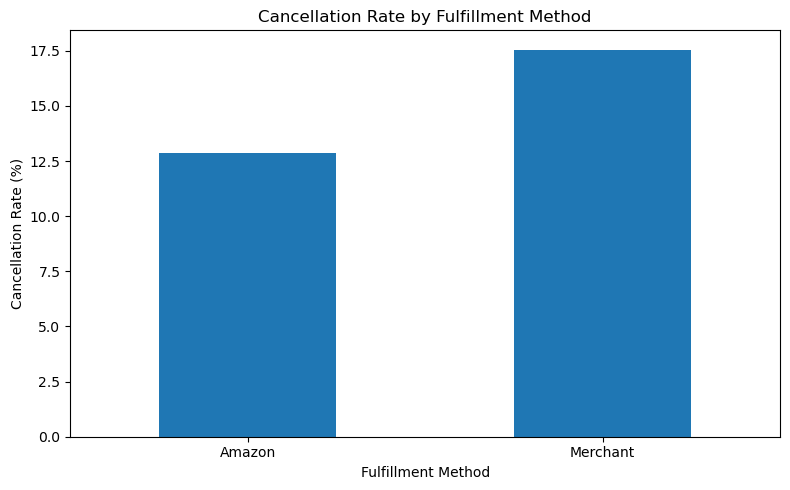

In [93]:
plt.figure(figsize=(8, 5))
cancellation_rate_by_fulfillment.plot(kind="bar")
plt.title("Cancellation Rate by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [94]:
returned_by_fulfillment = (df[df["Status"].isin(["Shipped - Returned to Seller","Shipped - Returning to Seller"]) ].groupby("Fulfilment")["Order ID"].nunique())
print(returned_by_fulfillment)

Fulfilment
Merchant    1980
Name: Order ID, dtype: int64


In [95]:
return_rate_by_fulfillment = (returned_by_fulfillment /total_orders_by_fulfillment) * 100
print(return_rate_by_fulfillment.round(2))

Fulfilment
Amazon       NaN
Merchant    5.45
Name: Order ID, dtype: float64


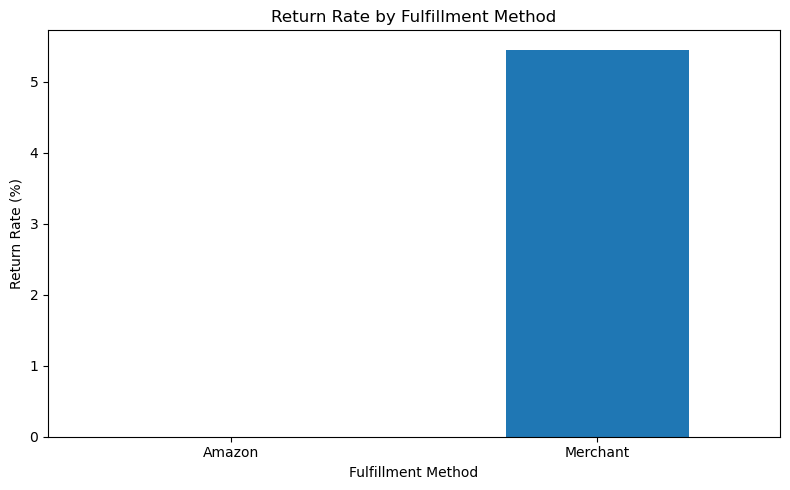

In [96]:
plt.figure(figsize=(8, 5))
return_rate_by_fulfillment.plot(kind="bar")
plt.title("Return Rate by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Return Rate (%)")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [97]:
stage4_summary = pd.DataFrame({
    "Orders": total_orders_by_fulfillment,
    "Sales": fulfillment_sales,
    "AOV": fulfillment_aov["AOV"],
    "Cancellation Rate (%)": cancellation_rate_by_fulfillment,
    "Return Rate (%)": return_rate_by_fulfillment
})

stage4_summary

,Orders,Sales,AOV,Cancellation Rate (%),Return Rate (%)
Fulfilment,,,,,
Amazon,83906,54262165.00,693.791986,12.860820,NaN
Merchant,36323,24234621.39,698.887455,17.550863,5.451092


In [98]:
b2b_orders = (
    df.groupby("B2B")["Order ID"]
    .nunique()
)

print(b2b_orders)

B2B
False    119435
True        794
Name: Order ID, dtype: int64


In [99]:
b2b_order_percentage = (
    b2b_orders / b2b_orders.sum()
) * 100

print(b2b_order_percentage.round(2))

B2B
False    99.34
True      0.66
Name: Order ID, dtype: float64


In [100]:
b2b_quantity = (
    df.groupby("B2B")["Qty"]
    .sum()
)

print(b2b_quantity)

B2B
False    115656
True        840
Name: Qty, dtype: int64


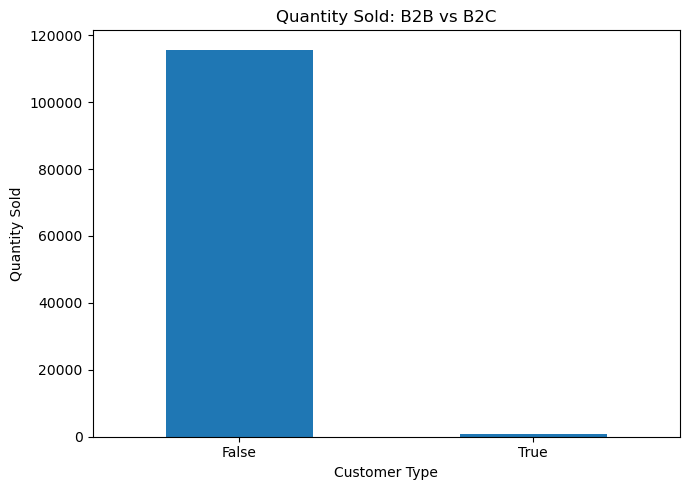

In [101]:
plt.figure(figsize=(7, 5))

b2b_quantity.plot(kind="bar")

plt.title("Quantity Sold: B2B vs B2C")
plt.xlabel("Customer Type")
plt.ylabel("Quantity Sold")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [102]:
b2b_sales = (
    sales_df.groupby("B2B")["Amount"]
    .sum()
)

print(b2b_sales)

B2B
False    77905565.60
True       591220.79
Name: Amount, dtype: float64


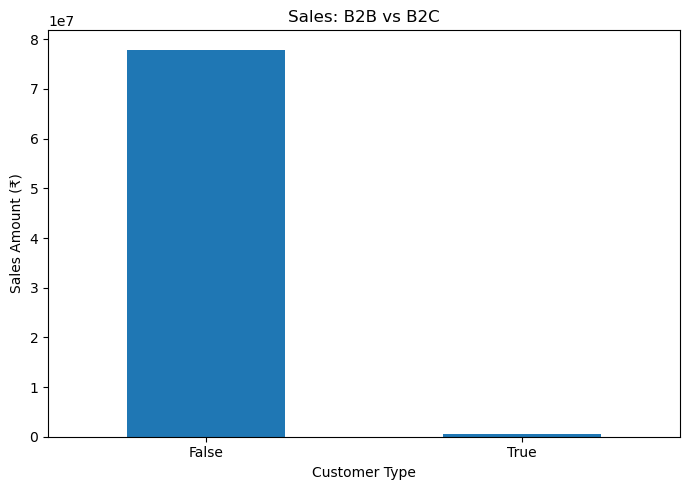

In [103]:
plt.figure(figsize=(7, 5))

b2b_sales.plot(kind="bar")

plt.title("Sales: B2B vs B2C")
plt.xlabel("Customer Type")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

             Sales  Orders         AOV
B2B                                   
False  77905565.60  112118  694.853330
True     591220.79     769  768.817672


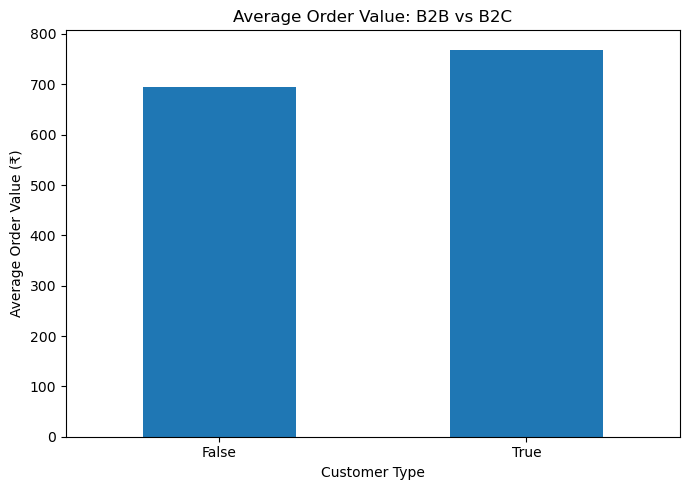

In [104]:
b2b_aov = (
    sales_df.groupby("B2B")
    .agg(
        Sales=("Amount", "sum"),
        Orders=("Order ID", "nunique")
    )
)

b2b_aov["AOV"] = (
    b2b_aov["Sales"] /
    b2b_aov["Orders"]
)

print(b2b_aov)
plt.figure(figsize=(7, 5))

b2b_aov["AOV"].plot(kind="bar")

plt.title("Average Order Value: B2B vs B2C")
plt.xlabel("Customer Type")
plt.ylabel("Average Order Value (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

B2B
False    17100
True        66
Name: Order ID, dtype: int64
B2B
False    14.32
True      8.31
Name: Order ID, dtype: float64


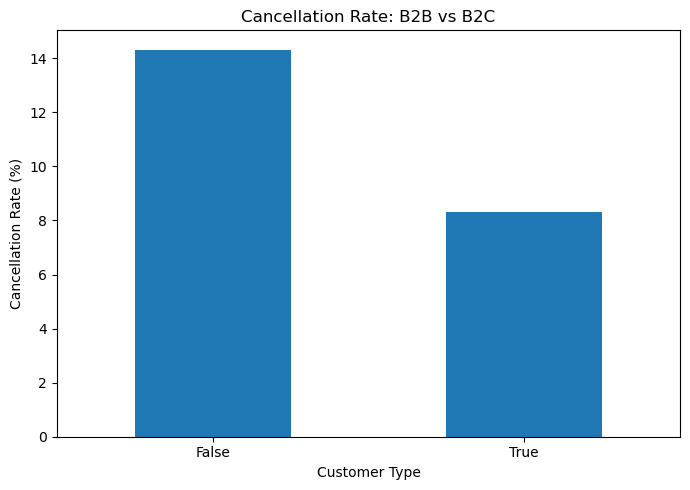

In [105]:
b2b_cancelled = (
    df[df["Status"] == "Cancelled"]
    .groupby("B2B")["Order ID"]
    .nunique()
)

print(b2b_cancelled)
b2b_cancellation_rate = (
    b2b_cancelled / b2b_orders
) * 100

print(b2b_cancellation_rate.round(2))
plt.figure(figsize=(7, 5))

b2b_cancellation_rate.plot(kind="bar")

plt.title("Cancellation Rate: B2B vs B2C")
plt.xlabel("Customer Type")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [106]:
b2b_returned = (
    df[
        df["Status"].isin([
            "Shipped - Returned to Seller",
            "Shipped - Returning to Seller"
        ])
    ]
    .groupby("B2B")["Order ID"]
    .nunique()
)

b2b_return_rate = (
    b2b_returned / b2b_orders
) * 100

print(b2b_return_rate.round(2))

B2B
False    1.65
True     0.76
Name: Order ID, dtype: float64


In [107]:
b2b_sales_percentage = (
    b2b_sales / b2b_sales.sum()
) * 100

print(b2b_sales_percentage.round(2))

B2B
False    99.25
True      0.75
Name: Amount, dtype: float64


In [108]:
stage5_summary = pd.DataFrame({
    "Orders": b2b_orders,
    "Order Share (%)": b2b_order_percentage,
    "Quantity": b2b_quantity,
    "Sales": b2b_sales,
    "Sales Share (%)": b2b_sales_percentage,
    "AOV": b2b_aov["AOV"],
    "Cancellation Rate (%)": b2b_cancellation_rate,
    "Return Rate (%)": b2b_return_rate
})

stage5_summary

,Orders,Order Share (%),Quantity,Sales,Sales Share (%),AOV,Cancellation Rate (%),Return Rate (%)
B2B,,,,,,,,
False,119435,99.339594,115656,77905565.60,99.246822,694.853330,14.317411,1.652782
True,794,0.660406,840,591220.79,0.753178,768.817672,8.312343,0.755668


In [109]:
stage5_summary.index = stage5_summary.index.map({
    False: "B2C",
    True: "B2B"
})

stage5_summary

,Orders,Order Share (%),Quantity,Sales,Sales Share (%),AOV,Cancellation Rate (%),Return Rate (%)
B2B,,,,,,,,
B2C,119435,99.339594,115656,77905565.60,99.246822,694.853330,14.317411,1.652782
B2B,794,0.660406,840,591220.79,0.753178,768.817672,8.312343,0.755668


In [110]:
print("Number of States:", df["ship-state"].nunique())
print("Number of Cities:", df["ship-city"].nunique())
print("Number of Countries:", df["ship-country"].nunique())

Number of States: 69
Number of Cities: 8948
Number of Countries: 1


In [111]:
state_orders = (
    df.groupby("ship-state")["Order ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(state_orders.head(10))

ship-state
MAHARASHTRA       20756
KARNATAKA         16162
TAMIL NADU        10507
TELANGANA         10394
UTTAR PRADESH     10057
DELHI              6347
KERALA             6097
WEST BENGAL        5645
ANDHRA PRADESH     4970
Gujarat            4161
Name: Order ID, dtype: int64


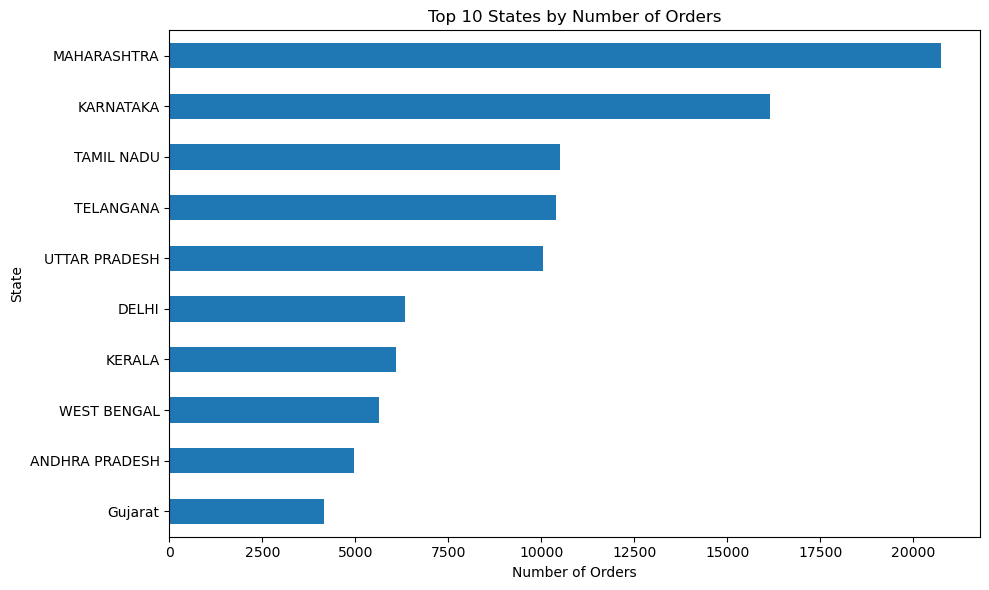

In [112]:
plt.figure(figsize=(10, 6))

state_orders.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("State")

plt.tight_layout()
plt.show()

ship-state
MAHARASHTRA       13318966.38
KARNATAKA         10465387.03
TELANGANA          6909670.08
UTTAR PRADESH      6814126.08
TAMIL NADU         6510503.73
DELHI              4228503.97
KERALA             3821997.58
WEST BENGAL        3503223.44
ANDHRA PRADESH     3214859.86
HARYANA            2879146.99
Name: Amount, dtype: float64


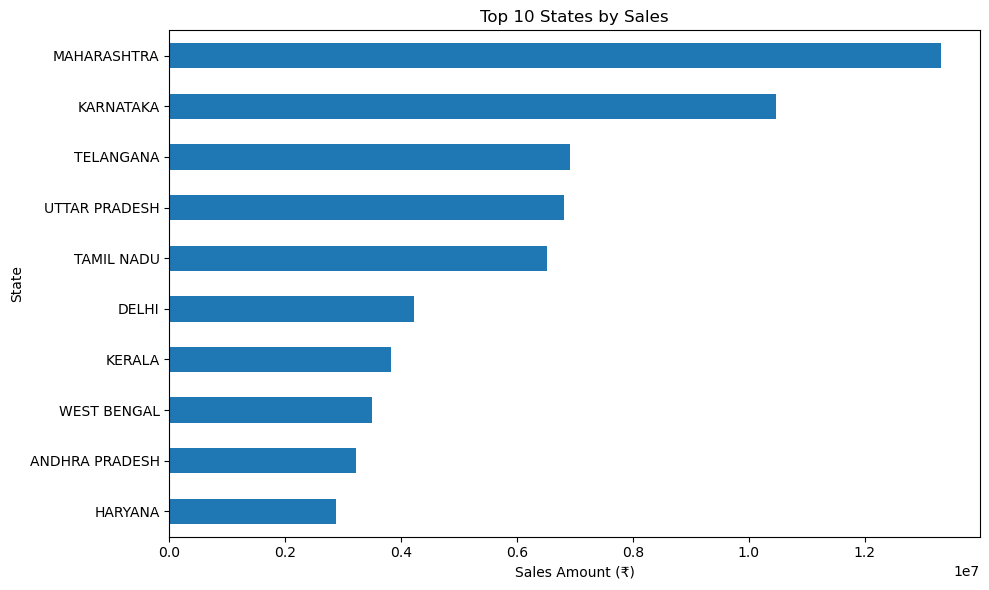

In [113]:
state_sales = (
    sales_df.groupby("ship-state")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(state_sales.head(10))
plt.figure(figsize=(10, 6))

state_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

ship-state
MAHARASHTRA       20304
KARNATAKA         15876
TAMIL NADU        10400
TELANGANA         10243
UTTAR PRADESH      9495
DELHI              6144
KERALA             5802
WEST BENGAL        5311
ANDHRA PRADESH     4810
Gujarat            4139
Name: Qty, dtype: int64


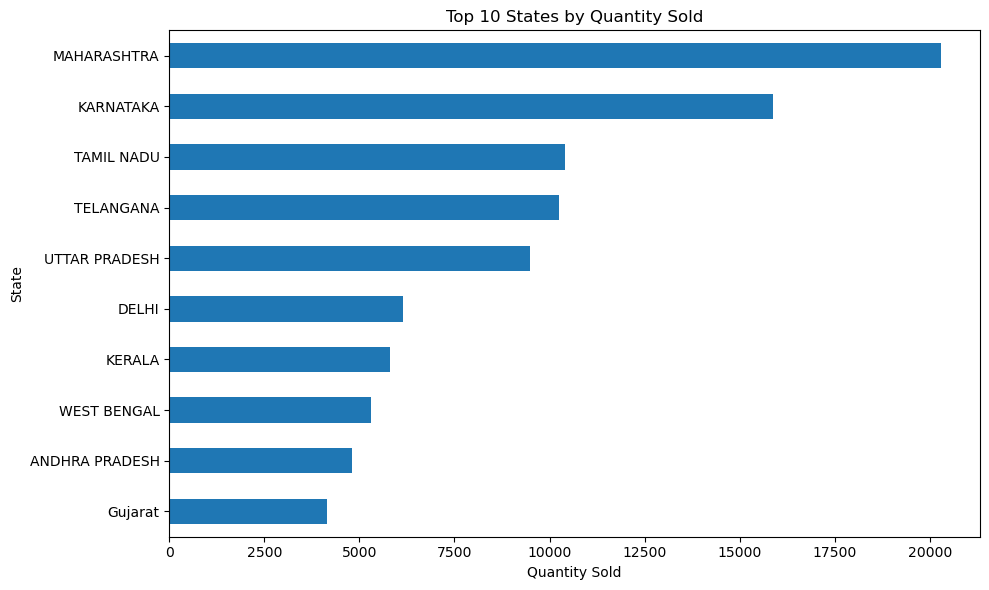

In [114]:
state_quantity = (
    df.groupby("ship-state")["Qty"]
    .sum()
    .sort_values(ascending=False)
)

print(state_quantity.head(10))
plt.figure(figsize=(10, 6))

state_quantity.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 States by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [115]:
state_sales_percentage = (
    state_sales / state_sales.sum()
) * 100

print(state_sales_percentage.head(10).round(2))

ship-state
MAHARASHTRA       16.97
KARNATAKA         13.34
TELANGANA          8.80
UTTAR PRADESH      8.68
TAMIL NADU         8.30
DELHI              5.39
KERALA             4.87
WEST BENGAL        4.46
ANDHRA PRADESH     4.10
HARYANA            3.67
Name: Amount, dtype: float64


ship-city
BENGALURU    10441
HYDERABAD     7404
MUMBAI        5645
NEW DELHI     5425
CHENNAI       4925
PUNE          3593
KOLKATA       2246
GURUGRAM      1768
THANE         1612
LUCKNOW       1393
Name: Order ID, dtype: int64


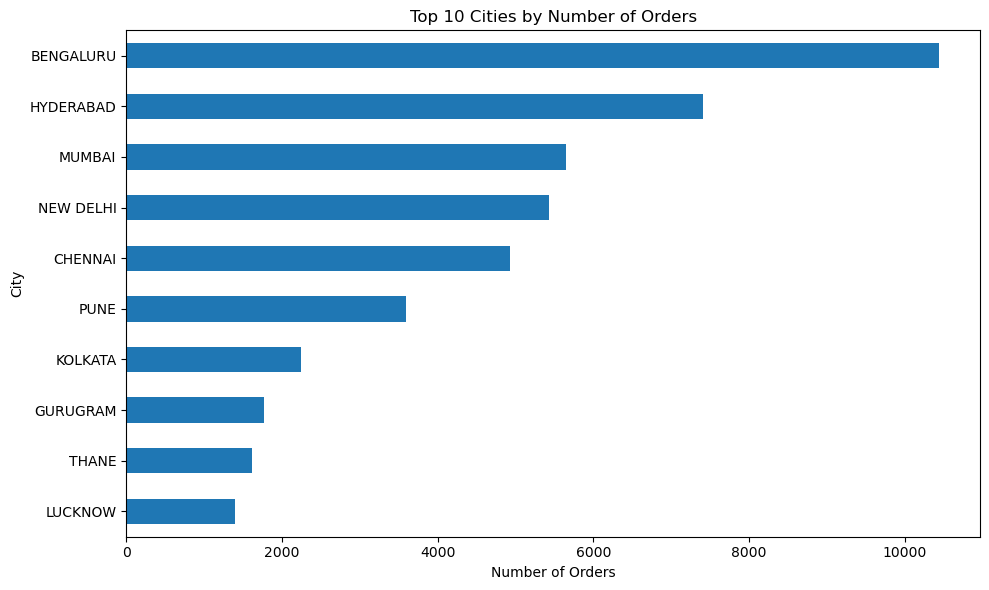

In [116]:
city_orders = (
    df.groupby("ship-city")["Order ID"]
    .nunique()
    .sort_values(ascending=False)
)

print(city_orders.head(10))
plt.figure(figsize=(10, 6))

city_orders.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Number of Orders")
plt.xlabel("Number of Orders")
plt.ylabel("City")

plt.tight_layout()
plt.show()

ship-city
BENGALURU    6836614.65
HYDERABAD    4941790.25
MUMBAI       3696704.04
NEW DELHI    3608277.78
CHENNAI      3098745.74
PUNE         2337978.18
KOLKATA      1412815.87
GURUGRAM     1220562.74
THANE        1003878.29
LUCKNOW       933926.34
Name: Amount, dtype: float64


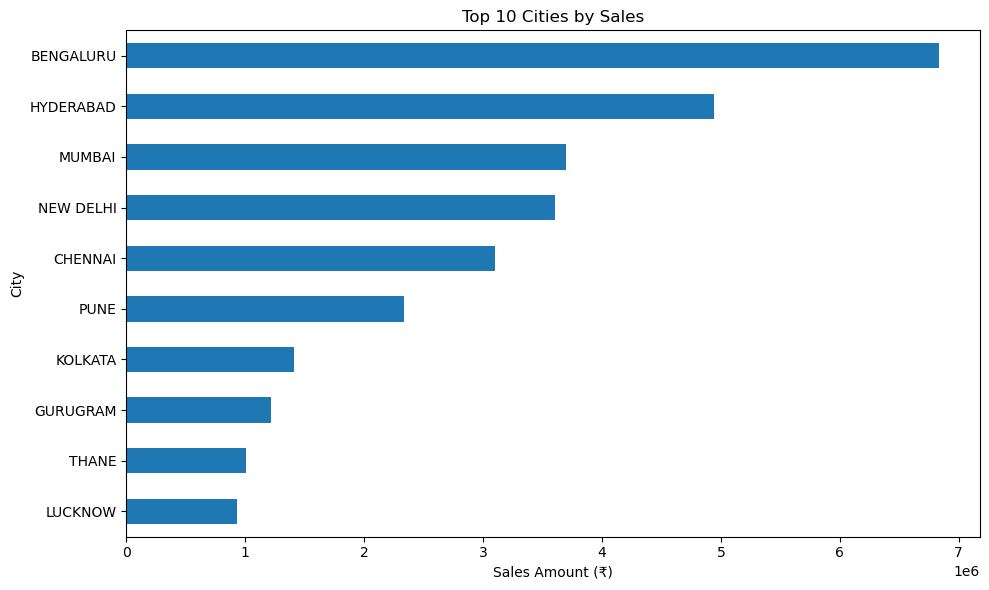

In [117]:
city_sales = (
    sales_df.groupby("ship-city")["Amount"]
    .sum()
    .sort_values(ascending=False)
)

print(city_sales.head(10))
plt.figure(figsize=(10, 6))

city_sales.head(10).sort_values().plot(kind="barh")

plt.title("Top 10 Cities by Sales")
plt.xlabel("Sales Amount (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

In [118]:
state_aov = (
    sales_df.groupby("ship-state")
    .agg(
        Sales=("Amount", "sum"),
        Orders=("Order ID", "nunique")
    )
)

state_aov["AOV"] = (
    state_aov["Sales"] /
    state_aov["Orders"]
)

state_aov = state_aov.sort_values(
    "AOV",
    ascending=False
)

print(state_aov.head(10))

                 Sales  Orders          AOV
ship-state                                 
bihar          1432.00       1  1432.000000
delhi         16553.62      16  1034.601250
LADAKH        38388.43      41   936.303171
Sikkim         2703.00       3   901.000000
NAGALAND     143430.67     162   885.374506
Chandigarh     9054.62      11   823.147273
LAKSHADWEEP    3175.29       4   793.822500
rajasthan      3946.00       5   789.200000
MANIPUR      209354.99     266   787.048835
Punjab        22013.00      28   786.178571


In [119]:
state_category_sales = pd.pivot_table(
    sales_df,
    values="Amount",
    index="ship-state",
    columns="Category",
    aggfunc="sum",
    fill_value=0
)

state_category_sales.head()
top_states = state_sales.head(10).index

top_state_category_sales = state_category_sales.loc[top_states]

top_state_category_sales

Category,Blazzer,Perfume,Shirt,Shoes,Socks,T-shirt,Trousers,Wallet,Watch
ship-state,,,,,,,,,
MAHARASHTRA,1997524.26,156525.24,3594094.26,16017.38,22941.81,6265529.71,1204376.96,61956.76,0.0
KARNATAKA,1636001.33,118580.25,2890245.07,16630.00,17359.87,4968181.28,711543.84,106540.39,305.0
TELANGANA,1300148.14,97842.00,2070619.75,5908.48,12641.67,3052170.54,331782.07,37947.43,610.0
UTTAR PRADESH,724321.84,57363.52,1475504.44,12186.62,11698.39,4084539.68,405913.48,42598.11,0.0
TAMIL NADU,955734.07,70268.28,2437756.96,22398.00,15843.53,2625648.29,338427.21,44427.39,0.0
DELHI,454877.77,41206.29,925096.52,6923.00,6348.00,2368311.67,404990.72,20750.00,0.0
KERALA,903635.28,18934.38,1242075.94,3718.00,7360.00,1475363.67,159066.93,11843.38,0.0
WEST BENGAL,430081.64,32863.00,1123075.54,9651.90,8929.00,1617492.62,263495.69,17634.05,0.0
ANDHRA PRADESH,524516.75,29615.52,1076233.18,1704.00,5112.39,1460727.77,99968.25,16982.00,0.0


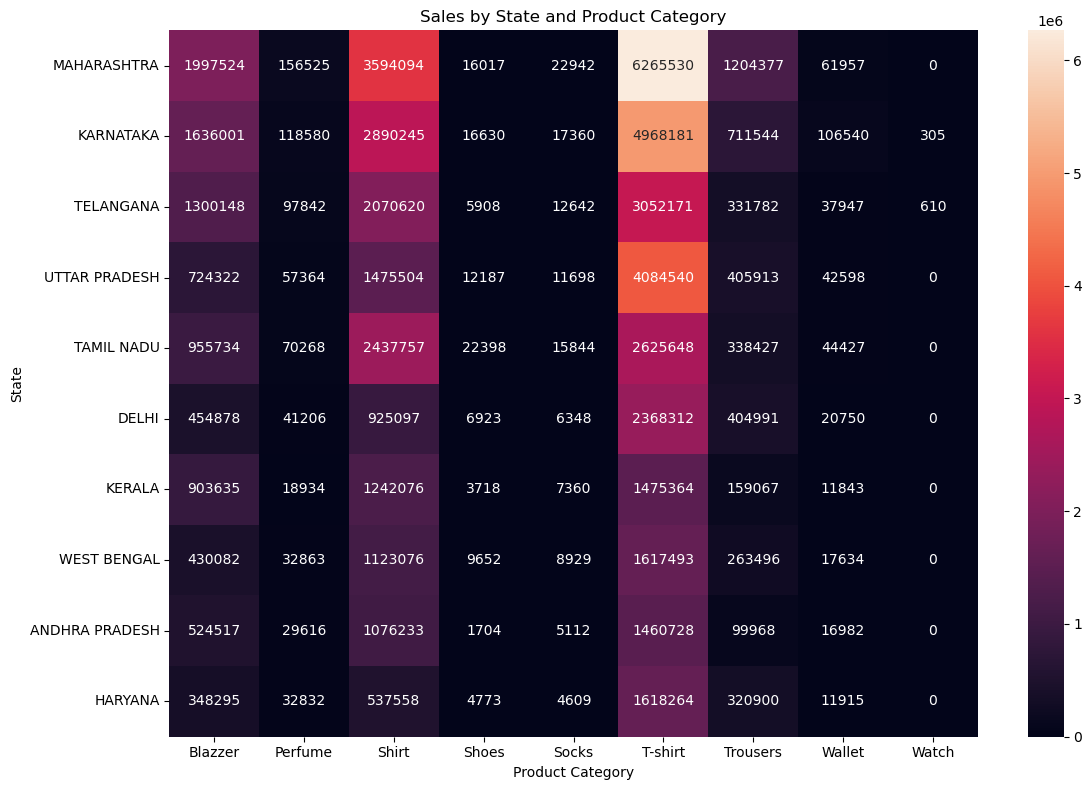

In [120]:
plt.figure(figsize=(12, 8))

sns.heatmap(
    top_state_category_sales,
    annot=True,
    fmt=".0f"
)

plt.title("Sales by State and Product Category")
plt.xlabel("Product Category")
plt.ylabel("State")

plt.tight_layout()
plt.show()

In [121]:
top_state = state_sales.idxmax()
top_state_sales = state_sales.max()

top_city = city_sales.idxmax()
top_city_sales = city_sales.max()

stage6_summary = pd.DataFrame({
    "Metric": [
        "Top State by Sales",
        "Top State Sales",
        "Top City by Sales",
        "Top City Sales",
        "Number of States",
        "Number of Cities"
    ],
    
    "Value": [
        top_state,
        top_state_sales,
        top_city,
        top_city_sales,
        df["ship-state"].nunique(),
        df["ship-city"].nunique()
    ]
})

stage6_summary

,Metric,Value
0,Top State by Sales,MAHARASHTRA
1,Top State Sales,13318966.38
2,Top City by Sales,BENGALURU
3,Top City Sales,6836614.65
4,Number of States,69
5,Number of Cities,8948


Courier Status
Shipped       109341
On the Way      6863
Unshipped       6675
Cancelled       5929
Name: count, dtype: int64


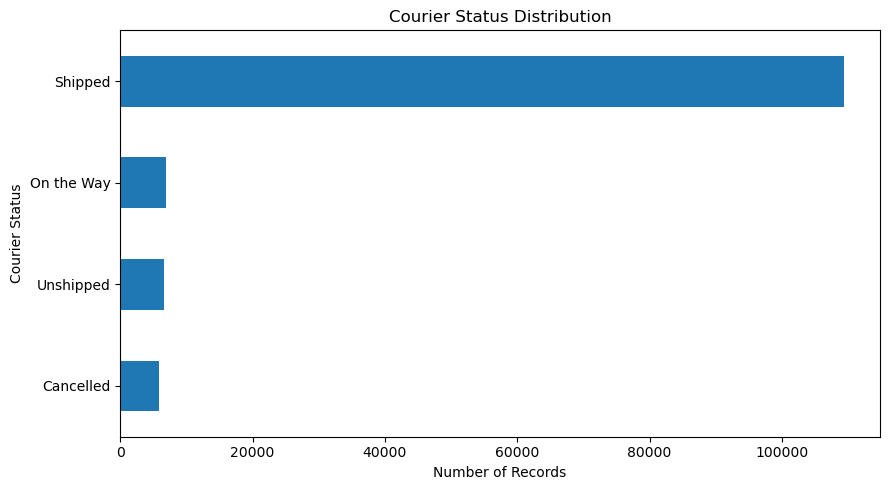

In [122]:
courier_counts = df["Courier Status"].value_counts()

print(courier_counts)
plt.figure(figsize=(9, 5))

courier_counts.sort_values().plot(kind="barh")

plt.title("Courier Status Distribution")
plt.xlabel("Number of Records")
plt.ylabel("Courier Status")

plt.tight_layout()
plt.show()


In [123]:
courier_percentage = (
    df["Courier Status"].value_counts(normalize=True) * 100
)

print(courier_percentage.round(2))

Courier Status
Shipped       84.89
On the Way     5.33
Unshipped      5.18
Cancelled      4.60
Name: proportion, dtype: float64


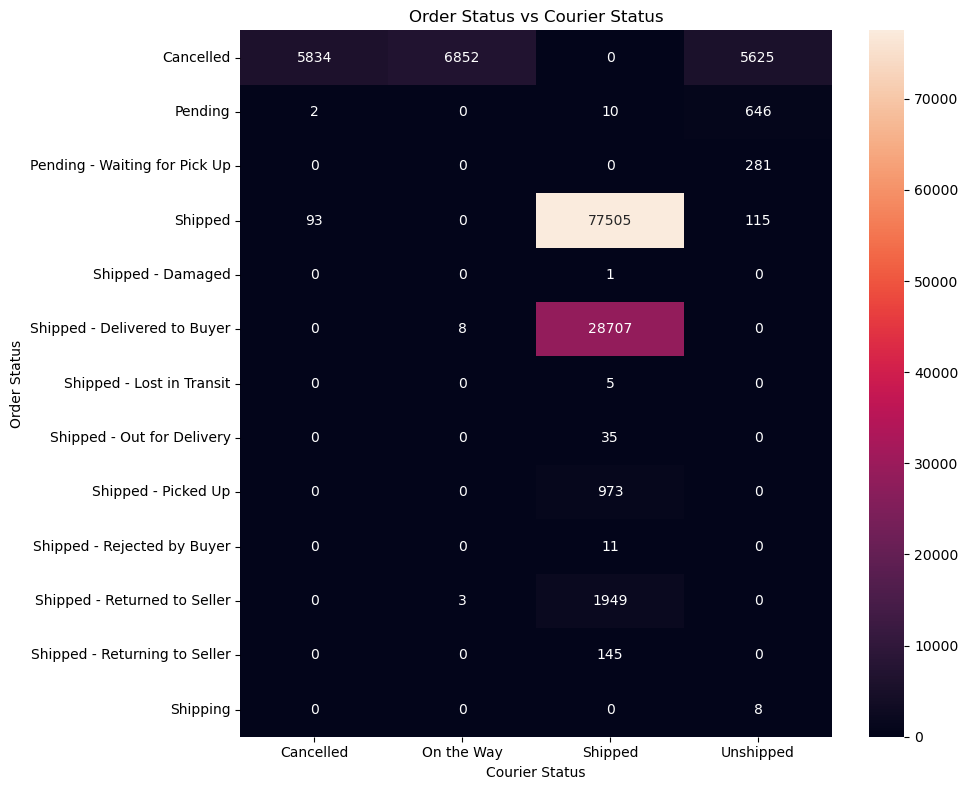

In [125]:
status_courier = pd.crosstab(
    df["Status"],
    df["Courier Status"]
)

status_courier
plt.figure(figsize=(10, 8))

sns.heatmap(
    status_courier,
    annot=True,
    fmt="d"
)

plt.title("Order Status vs Courier Status")
plt.xlabel("Courier Status")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

Fulfilment
Amazon      12.86
Merchant    17.55
Name: Order ID, dtype: float64


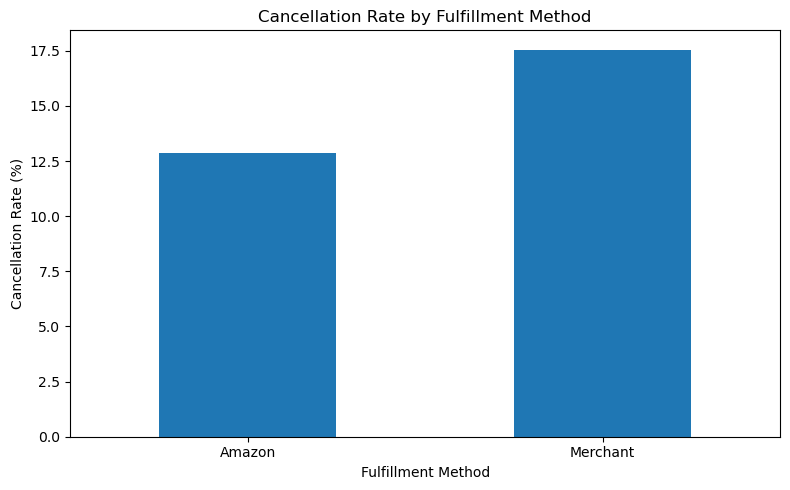

In [126]:
cancelled_fulfillment = (
    df[df["Status"] == "Cancelled"]
    .groupby("Fulfilment")["Order ID"]
    .nunique()
)

total_fulfillment_orders = (
    df.groupby("Fulfilment")["Order ID"]
    .nunique()
)

fulfillment_cancel_rate = (
    cancelled_fulfillment /
    total_fulfillment_orders
) * 100

print(fulfillment_cancel_rate.round(2))
plt.figure(figsize=(8, 5))

fulfillment_cancel_rate.plot(kind="bar")

plt.title("Cancellation Rate by Fulfillment Method")
plt.xlabel("Fulfillment Method")
plt.ylabel("Cancellation Rate (%)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [127]:
returned_statuses = [
    "Shipped - Returned to Seller",
    "Shipped - Returning to Seller"
]

returned_data = df[
    df["Status"].isin(returned_statuses)
].copy()

print("Returned Records:", len(returned_data))
print(
    "Returned Unique Orders:",
    returned_data["Order ID"].nunique()
)

Returned Records: 2097
Returned Unique Orders: 1980


Status
Shipped - Returned to Seller     1952
Shipped - Returning to Seller     145
Name: count, dtype: int64


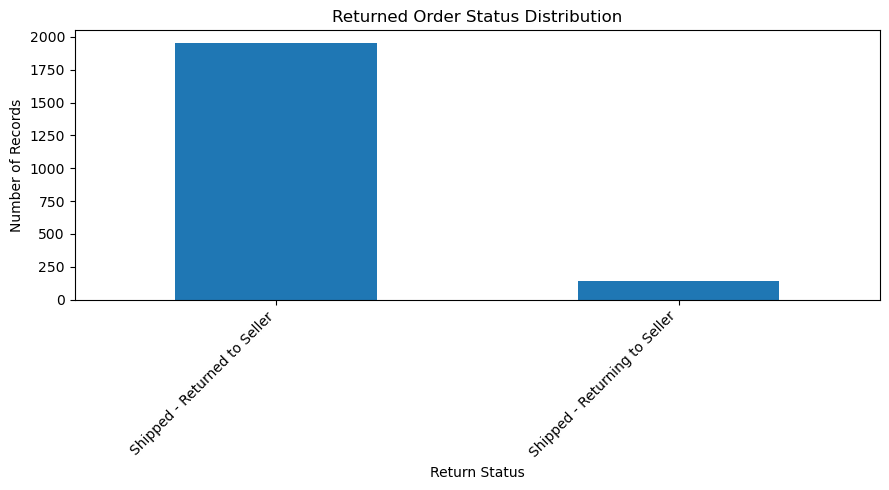

In [128]:
return_status_counts = (
    returned_data["Status"]
    .value_counts()
)

print(return_status_counts)
plt.figure(figsize=(9, 5))

return_status_counts.plot(kind="bar")

plt.title("Returned Order Status Distribution")
plt.xlabel("Return Status")
plt.ylabel("Number of Records")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()

In [129]:
pending_statuses = [
    "Pending",
    "Pending - Waiting for Pick Up"
]

pending_orders = df[
    df["Status"].isin(pending_statuses)
]["Order ID"].nunique()

pending_rate = (
    pending_orders / total_orders
) * 100

print("Pending Unique Orders:", pending_orders)
print("Pending Order Rate:", round(pending_rate, 2), "%")

Pending Unique Orders: 846
Pending Order Rate: 0.7 %


In [130]:
delivered_orders = df[
    df["Status"] == "Shipped - Delivered to Buyer"
]["Order ID"].nunique()

delivered_rate = (
    delivered_orders / total_orders
) * 100

print("Delivered Orders:", delivered_orders)
print("Delivered Order Rate:", round(delivered_rate, 2), "%")

Delivered Orders: 26521
Delivered Order Rate: 22.06 %


In [131]:
stage7_summary = pd.DataFrame({
    "Metric": [
        "Total Unique Orders",
        "Cancelled Orders",
        "Cancellation Rate (%)",
        "Returned Orders",
        "Return Rate (%)",
        "Pending Orders",
        "Pending Rate (%)",
        "Delivered Orders",
        "Delivered Rate (%)"
    ],
    
    "Value": [
        total_orders,
        cancelled_orders,
        cancellation_rate,
        returned_orders,
        return_rate,
        pending_orders,
        pending_rate,
        delivered_orders,
        delivered_rate
    ]
})

stage7_summary

,Metric,Value
0,Total Unique Orders,120229.000000
1,Cancelled Orders,17166.000000
2,Cancellation Rate (%),14.277753
3,Returned Orders,1980.000000
4,Return Rate (%),1.646857
5,Pending Orders,846.000000
6,Pending Rate (%),0.703657
7,Delivered Orders,26521.000000
8,Delivered Rate (%),22.058738


In [132]:
print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Return Rate:", round(return_rate, 2), "%")
print("Pending Rate:", round(pending_rate, 2), "%")
print("Delivered Rate:", round(delivered_rate, 2), "%")

Cancellation Rate: 14.28 %
Return Rate: 1.65 %
Pending Rate: 0.7 %
Delivered Rate: 22.06 %


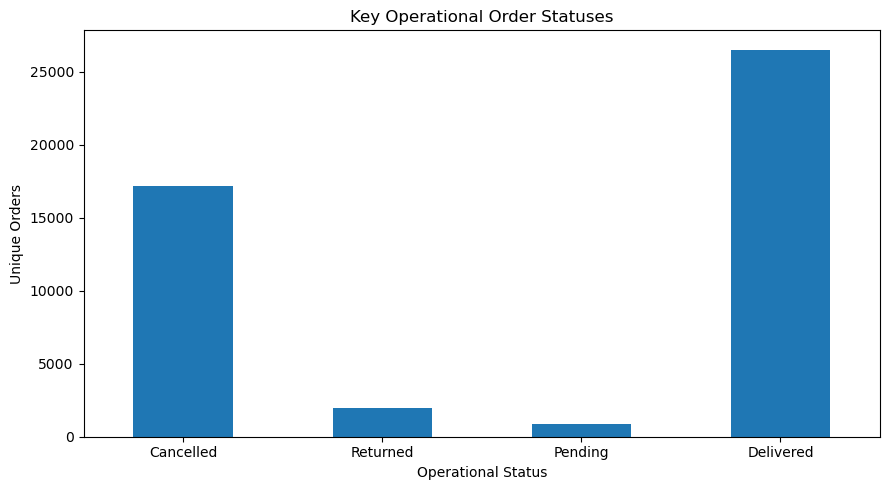

In [133]:
operational_status = pd.Series({
    "Cancelled": cancelled_orders,
    "Returned": returned_orders,
    "Pending": pending_orders,
    "Delivered": delivered_orders
})

plt.figure(figsize=(9, 5))

operational_status.plot(kind="bar")

plt.title("Key Operational Order Statuses")
plt.xlabel("Operational Status")
plt.ylabel("Unique Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

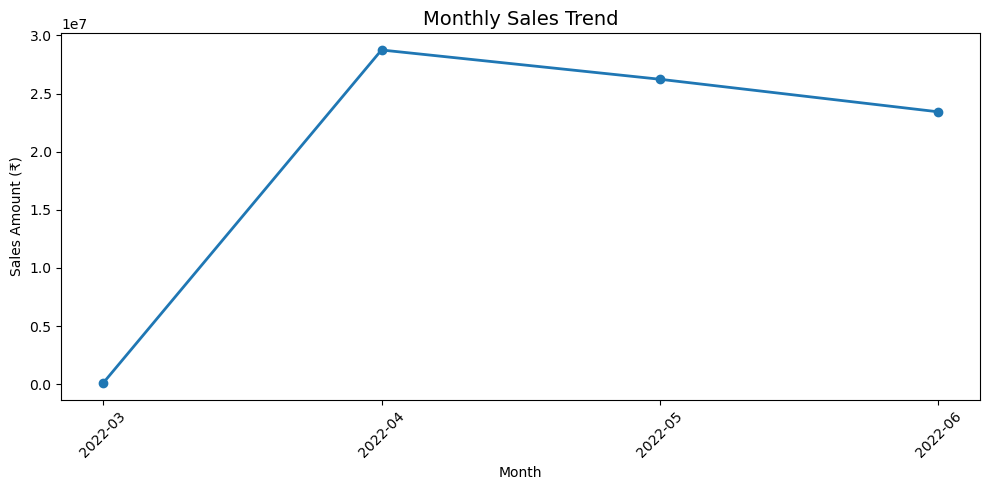

In [135]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

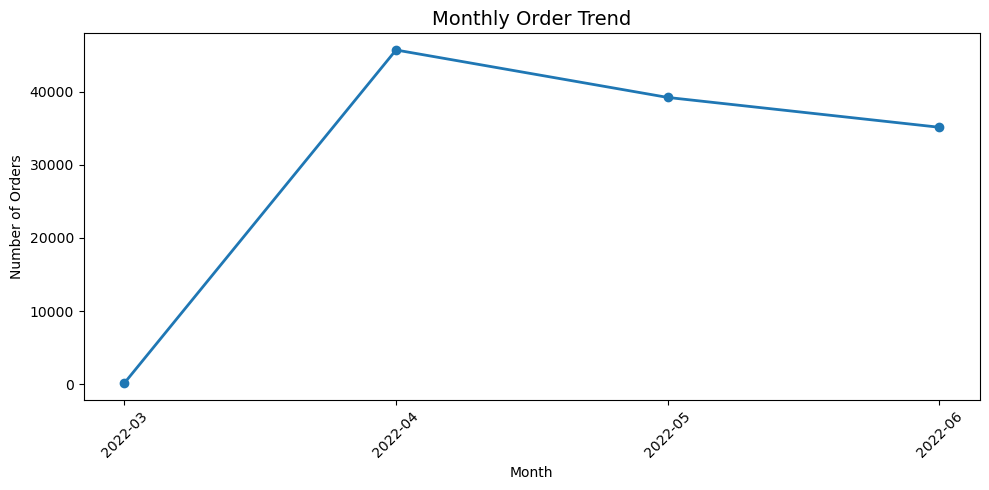

In [136]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_orders.index.astype(str),
    monthly_orders.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Order Trend", fontsize=14)
plt.xlabel("Month")
plt.ylabel("Number of Orders")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

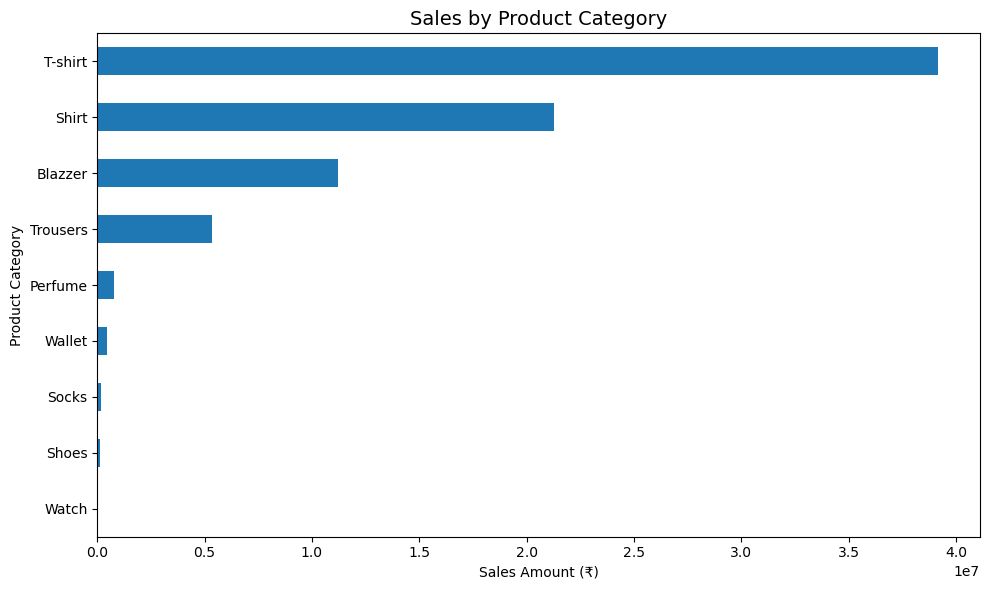

In [137]:
plt.figure(figsize=(10, 6))

category_sales.sort_values().plot(
    kind="barh"
)

plt.title("Sales by Product Category", fontsize=14)
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Product Category")

plt.tight_layout()
plt.show()

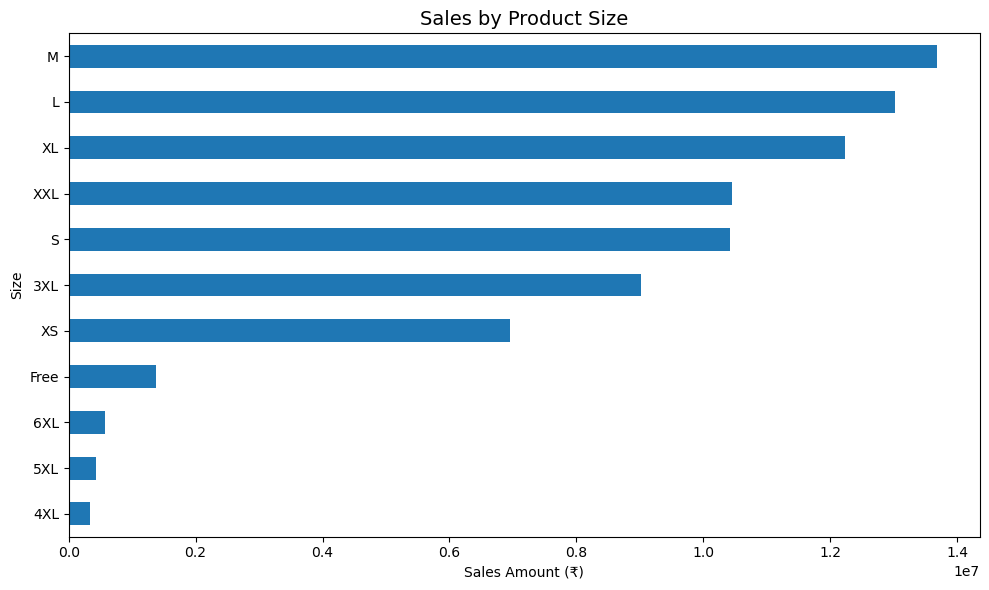

In [138]:
plt.figure(figsize=(10, 6))

size_sales.sort_values().plot(
    kind="barh"
)

plt.title("Sales by Product Size", fontsize=14)
plt.xlabel("Sales Amount (₹)")
plt.ylabel("Size")

plt.tight_layout()
plt.show()

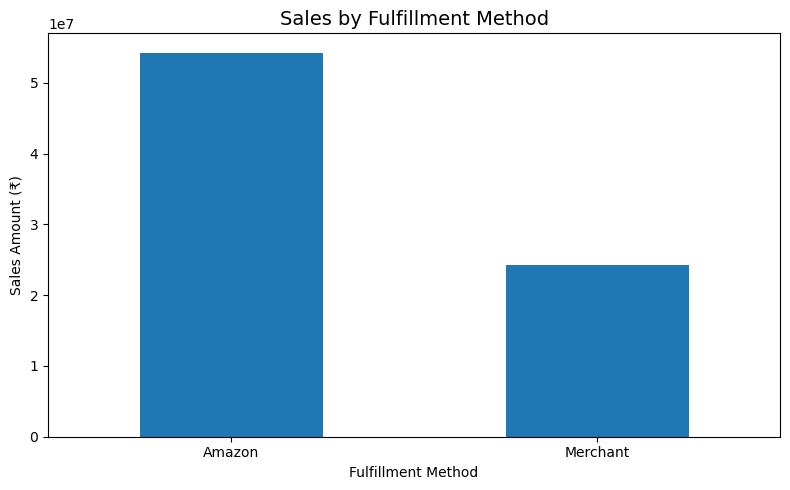

In [139]:
plt.figure(figsize=(8, 5))

fulfillment_sales.plot(
    kind="bar"
)

plt.title("Sales by Fulfillment Method", fontsize=14)
plt.xlabel("Fulfillment Method")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

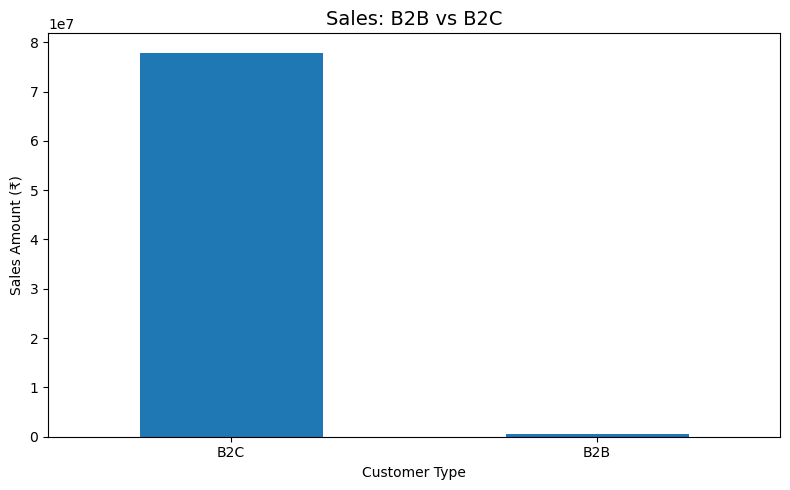

In [140]:
plt.figure(figsize=(8, 5))

b2b_sales.plot(
    kind="bar"
)

plt.title("Sales: B2B vs B2C", fontsize=14)
plt.xlabel("Customer Type")
plt.ylabel("Sales Amount (₹)")
plt.xticks(
    ticks=range(len(b2b_sales)),
    labels=["B2C", "B2B"],
    rotation=0
)

plt.tight_layout()
plt.show()

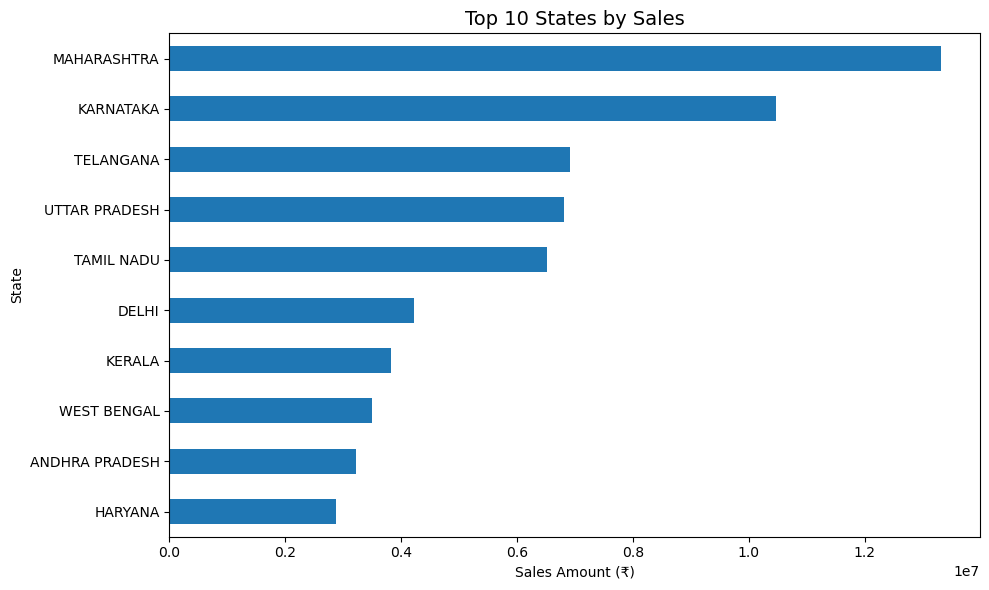

In [141]:
top_10_states = state_sales.head(10)

plt.figure(figsize=(10, 6))

top_10_states.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 States by Sales", fontsize=14)
plt.xlabel("Sales Amount (₹)")
plt.ylabel("State")

plt.tight_layout()
plt.show()

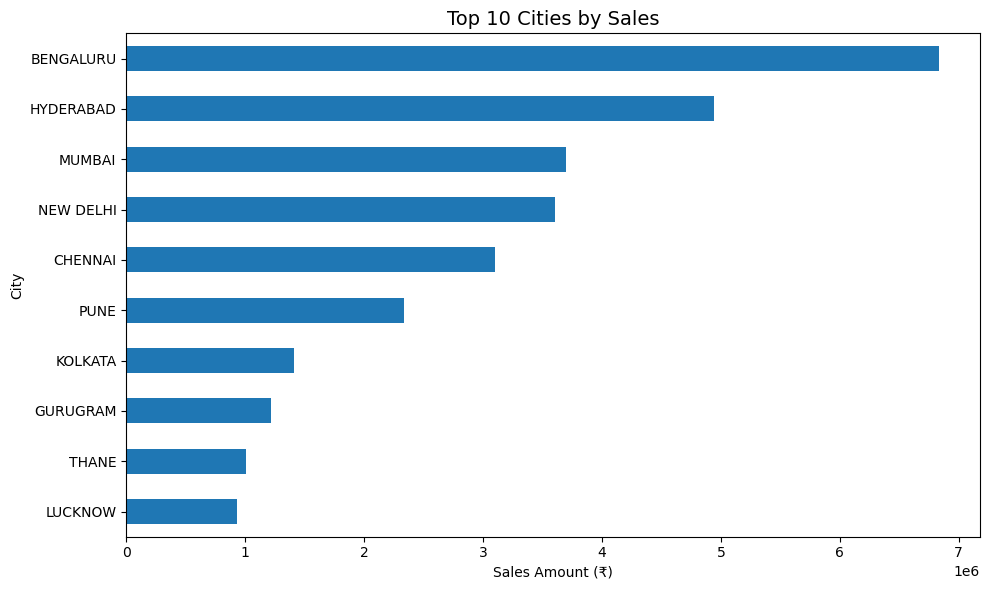

In [142]:
top_10_cities = city_sales.head(10)

plt.figure(figsize=(10, 6))

top_10_cities.sort_values().plot(
    kind="barh"
)

plt.title("Top 10 Cities by Sales", fontsize=14)
plt.xlabel("Sales Amount (₹)")
plt.ylabel("City")

plt.tight_layout()
plt.show()

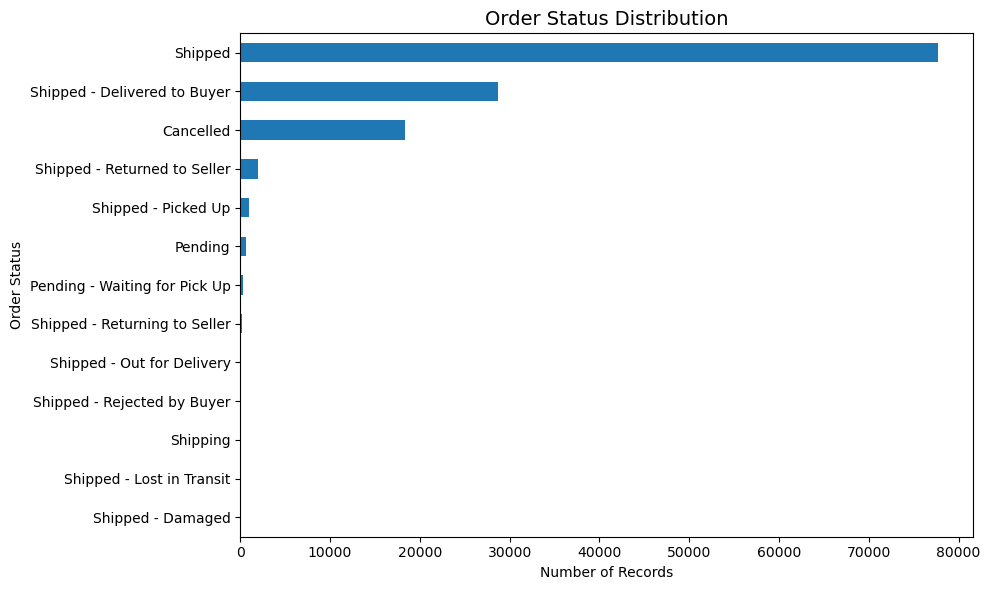

In [143]:
plt.figure(figsize=(10, 6))

status_counts.sort_values().plot(
    kind="barh"
)

plt.title("Order Status Distribution", fontsize=14)
plt.xlabel("Number of Records")
plt.ylabel("Order Status")

plt.tight_layout()
plt.show()

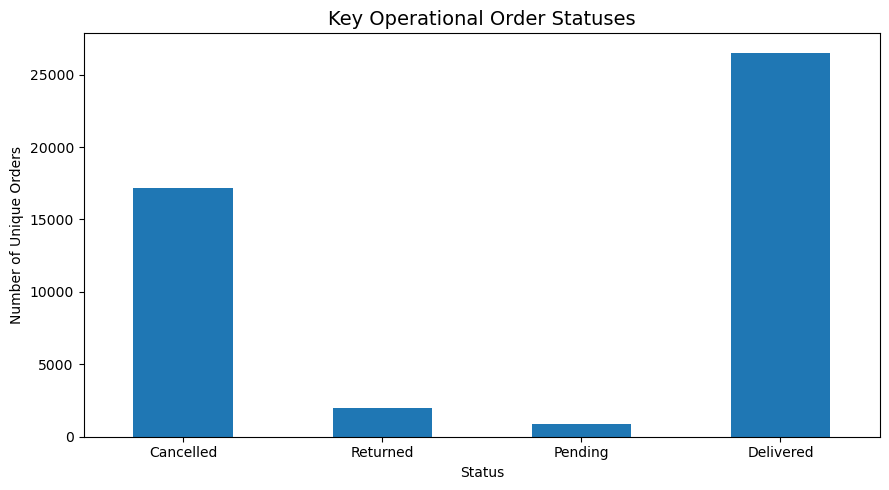

In [144]:
operational_status = pd.Series({
    "Cancelled": cancelled_orders,
    "Returned": returned_orders,
    "Pending": pending_orders,
    "Delivered": delivered_orders
})

plt.figure(figsize=(9, 5))

operational_status.plot(
    kind="bar"
)

plt.title("Key Operational Order Statuses", fontsize=14)
plt.xlabel("Status")
plt.ylabel("Number of Unique Orders")
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [145]:
final_kpis = pd.DataFrame({
    "KPI": [
        "Total Unique Orders",
        "Total Quantity Sold",
        "Total Sales",
        "Average Order Value",
        "Cancellation Rate",
        "Return Rate",
        "Pending Rate",
        "Delivered Rate"
    ],
    
    "Value": [
        total_orders,
        total_quantity,
        total_sales,
        aov,
        cancellation_rate,
        return_rate,
        pending_rate,
        delivered_rate
    ]
})

final_kpis

,KPI,Value
0,Total Unique Orders,1.202290e+05
1,Total Quantity Sold,1.164960e+05
2,Total Sales,7.849679e+07
3,Average Order Value,6.953572e+02
4,Cancellation Rate,1.427775e+01
5,Return Rate,1.646857e+00
6,Pending Rate,7.036572e-01
7,Delivered Rate,2.205874e+01


In [146]:
final_kpis_display = final_kpis.copy()

for i, row in final_kpis_display.iterrows():

    if row["KPI"] == "Total Sales":
        final_kpis_display.loc[i, "Value"] = f"₹{row['Value']:,.2f}"

    elif row["KPI"] == "Average Order Value":
        final_kpis_display.loc[i, "Value"] = f"₹{row['Value']:,.2f}"

    elif "Rate" in row["KPI"]:
        final_kpis_display.loc[i, "Value"] = f"{row['Value']:.2f}%"

    else:
        final_kpis_display.loc[i, "Value"] = f"{row['Value']:,.0f}"

final_kpis_display

C:\Users\Bhuva\AppData\Local\Temp\ipykernel_9368\302562876.py:15: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '120,229' has dtype incompatible with float64, please explicitly cast to a compatible dtype first.
  final_kpis_display.loc[i, "Value"] = f"{row['Value']:,.0f}"


,KPI,Value
0,Total Unique Orders,"120,229"
1,Total Quantity Sold,"116,496"
2,Total Sales,"₹78,496,786.39"
3,Average Order Value,₹695.36
4,Cancellation Rate,14.28%
5,Return Rate,1.65%
6,Pending Rate,0.70%
7,Delivered Rate,22.06%


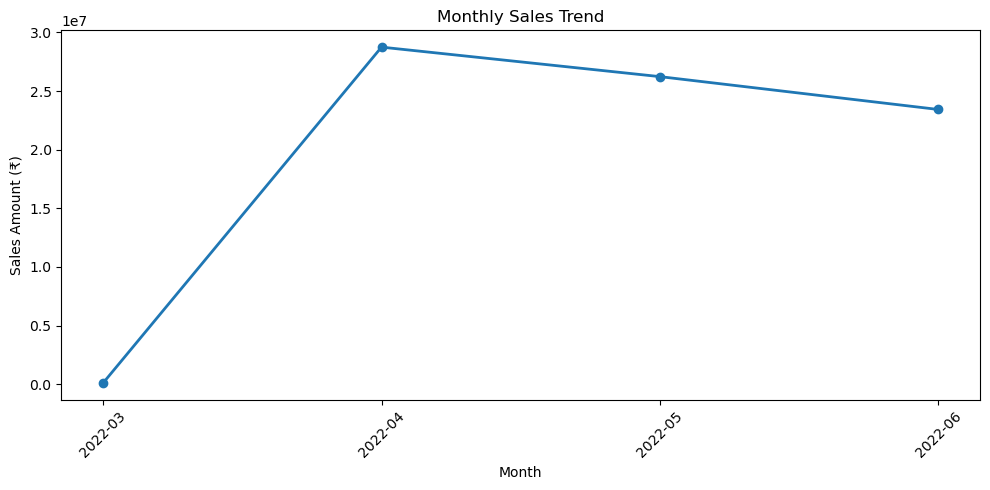

In [147]:
plt.figure(figsize=(10, 5))

plt.plot(
    monthly_sales.index.astype(str),
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales Amount (₹)")
plt.xticks(rotation=45)

plt.tight_layout()

plt.savefig(
    "monthly_sales_trend.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [148]:
stage3

,Metric,Value
0,Best Selling Category,T-shirt
1,Best Category Sales,39154132.17
2,Best Selling Price,M
3,Best Size Sales,13678295.13


In [149]:
stage4_summary

,Orders,Sales,AOV,Cancellation Rate (%),Return Rate (%)
Fulfilment,,,,,
Amazon,83906,54262165.00,693.791986,12.860820,NaN
Merchant,36323,24234621.39,698.887455,17.550863,5.451092


In [150]:
stage5_summary

,Orders,Order Share (%),Quantity,Sales,Sales Share (%),AOV,Cancellation Rate (%),Return Rate (%)
B2B,,,,,,,,
B2C,119435,99.339594,115656,77905565.60,99.246822,694.853330,14.317411,1.652782
B2B,794,0.660406,840,591220.79,0.753178,768.817672,8.312343,0.755668


In [151]:
stage6_summary

,Metric,Value
0,Top State by Sales,MAHARASHTRA
1,Top State Sales,13318966.38
2,Top City by Sales,BENGALURU
3,Top City Sales,6836614.65
4,Number of States,69
5,Number of Cities,8948


In [152]:
stage7_summary

,Metric,Value
0,Total Unique Orders,120229.000000
1,Cancelled Orders,17166.000000
2,Cancellation Rate (%),14.277753
3,Returned Orders,1980.000000
4,Return Rate (%),1.646857
5,Pending Orders,846.000000
6,Pending Rate (%),0.703657
7,Delivered Orders,26521.000000
8,Delivered Rate (%),22.058738


In [153]:
category_sales

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Wallet        458408.18
Socks         150397.50
Shoes         123933.76
Watch            915.00
Name: Amount, dtype: float64

In [154]:
size_sales

Size
M       13678295.13
L       13023938.84
XL      12240095.38
XXL     10452621.64
S       10414943.18
3XL      9026104.92
XS       6952253.10
Free     1372676.60
6XL       576249.33
5XL       425156.63
4XL       334451.64
Name: Amount, dtype: float64

In [155]:
state_sales.head(10)

ship-state
MAHARASHTRA       13318966.38
KARNATAKA         10465387.03
TELANGANA          6909670.08
UTTAR PRADESH      6814126.08
TAMIL NADU         6510503.73
DELHI              4228503.97
KERALA             3821997.58
WEST BENGAL        3503223.44
ANDHRA PRADESH     3214859.86
HARYANA            2879146.99
Name: Amount, dtype: float64

In [156]:
city_sales.head(10)

ship-city
BENGALURU    6836614.65
HYDERABAD    4941790.25
MUMBAI       3696704.04
NEW DELHI    3608277.78
CHENNAI      3098745.74
PUNE         2337978.18
KOLKATA      1412815.87
GURUGRAM     1220562.74
THANE        1003878.29
LUCKNOW       933926.34
Name: Amount, dtype: float64

In [158]:
print("SALES FINDINGS")

print("Best Sales Month:", best_month)
print("Best Month Sales: ₹", round(best_month_sales, 2))

print("Lowest Sales Month:", lowest_month)
print("Lowest Month Sales: ₹", round(lowest_month_sales, 2))

print("Total Sales: ₹", round(total_sales, 2))
print("Average Order Value: ₹", round(aov, 2))
print("Cancellation Rate:", round(cancellation_rate, 2), "%")
print("Return Rate:", round(return_rate, 2), "%")

SALES FINDINGS
Best Sales Month: 2022-04
Best Month Sales: ₹ 28742816.41
Lowest Sales Month: 2022-03
Lowest Month Sales: ₹ 101683.85
Total Sales: ₹ 78496786.39
Average Order Value: ₹ 695.36
Cancellation Rate: 14.28 %
Return Rate: 1.65 %


In [159]:
print("PRODUCT FINDINGS")

print("Best-Selling Category:", best_category)
print("Category Sales: ₹", round(best_category_sales, 2))

print("Best-Selling Size:", best_size)
print("Size Sales: ₹", round(best_size_sales, 2))

PRODUCT FINDINGS
Best-Selling Category: T-shirt
Category Sales: ₹ 39154132.17
Best-Selling Size: M
Size Sales: ₹ 13678295.13


In [160]:
print("GEOGRAPHICAL FINDINGS")

print("Top State:", top_state)
print("Top State Sales: ₹", round(top_state_sales, 2))

print("Top City:", top_city)
print("Top City Sales: ₹", round(top_city_sales, 2))

GEOGRAPHICAL FINDINGS
Top State: MAHARASHTRA
Top State Sales: ₹ 13318966.38
Top City: BENGALURU
Top City Sales: ₹ 6836614.65


In [161]:
print(category_sales.head(5))

Category
T-shirt     39154132.17
Shirt       21269768.70
Blazzer     11208506.12
Trousers     5341305.30
Perfume       789419.66
Name: Amount, dtype: float64


In [162]:
print(size_sales.head(5))

Size
M      13678295.13
L      13023938.84
XL     12240095.38
XXL    10452621.64
S      10414943.18
Name: Amount, dtype: float64


In [163]:
print(size_quantity.head(5))

Size
M      20116
L      19680
XL     18609
XXL    16226
S      15022
Name: Qty, dtype: int64


In [164]:
print(state_sales.head(10))

ship-state
MAHARASHTRA       13318966.38
KARNATAKA         10465387.03
TELANGANA          6909670.08
UTTAR PRADESH      6814126.08
TAMIL NADU         6510503.73
DELHI              4228503.97
KERALA             3821997.58
WEST BENGAL        3503223.44
ANDHRA PRADESH     3214859.86
HARYANA            2879146.99
Name: Amount, dtype: float64


In [165]:
print(city_sales.head(10))

ship-city
BENGALURU    6836614.65
HYDERABAD    4941790.25
MUMBAI       3696704.04
NEW DELHI    3608277.78
CHENNAI      3098745.74
PUNE         2337978.18
KOLKATA      1412815.87
GURUGRAM     1220562.74
THANE        1003878.29
LUCKNOW       933926.34
Name: Amount, dtype: float64
